# NUS Curriculum & Job Alignment Framework

This notebook implements a scalable, validated framework for assessing alignment between NUS degree programmes (constructed from `modules.csv`) and MyCareersFuture job advertisements.

**Objective:** Provide MOE with a credible, systematic framework for curriculum-job alignment analysis at the degree level.

**Sections:**
0. Setup
1. Data Loading & Preprocessing
2. Degree Profile Construction
3. Semantic Embedding
4. Baseline Cosine Similarity Retrieval
5. Job-Skill Coverage Score (Hybrid Alignment)
6. Job Clustering (Scalability Layer)
7. Evaluation Framework
8. Results Summary & Interpretation

---
## Section 0: Setup

In [1]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

JOB_CORPUS_VERSION = 'targeted_dedup_v3'
SEMANTIC_RETRIEVAL_VERSION = 'module_top5_job120_v2'
JOB_DESC_WORD_LIMIT = 120
DEGREE_MODULE_TOP_K = 5
SKILL_SIGNAL_VERSION = 'job_skill_coverage_v2'
COMMON_SKILL_SHARE_THRESHOLD = 0.08

PROJECT_LIKE_TITLE_PATTERN = re.compile(
    r'\b(capstone|dissertation|final year project|fyp|independent study|internship|practicum|project|research project|seminar|special topics?|thesis)\b',
    flags=re.IGNORECASE,
)

GENERIC_SKILL_STOPLIST = {
    'able', 'adaptability', 'adaptable', 'analysis', 'applications', 'articulate',
    'arts', 'basic', 'capital', 'case analysis', 'cleaning', 'code', 'collaborative',
    'collaboration', 'communicate', 'communication', 'communication skills',
    'community', 'components', 'detail oriented', 'independent', 'interpersonal skills',
    'leadership', 'motivated', 'multitasking', 'organized', 'positive attitude',
    'problem solving', 'problem-solving', 'responsible', 'self motivated',
    'self-motivated', 'team player', 'teamwork', 'willing to learn'
}

SHORT_SKILL_WHITELIST = {
    'r', 'c', 'c++', 'c#', 'ai', 'ml', 'nlp', 'sql', 'aws', 'gcp', 'sap', 'api',
    'apis', 'etl', 'erp', 'gis', 'seo', 'sem', 'crm', 'cad', 'ui', 'ux', 'qa', 'bi'
}

JOB_DESCRIPTION_DROP_PATTERNS = [
    re.compile(r'\bea (?:licen[cs]e|personnel|reg(?:istration)?) no\b', flags=re.IGNORECASE),
    re.compile(r'\bwe regret that only shortlisted candidates\b', flags=re.IGNORECASE),
    re.compile(r'\binterested applicants\b', flags=re.IGNORECASE),
    re.compile(r'\bapply now\b', flags=re.IGNORECASE),
    re.compile(r'\bby submitting your resume\b', flags=re.IGNORECASE),
    re.compile(r'\bpersonal data\b', flags=re.IGNORECASE),
    re.compile(r'\bfor quicker response\b', flags=re.IGNORECASE),
]

# ── Paths ──────────────────────────────────────────────────────────────────────
if Path.cwd().name == 'notebooks':
    REPO_ROOT = Path('..').resolve()
else:
    REPO_ROOT = Path('.').resolve()
DATA_DIR       = REPO_ROOT / 'data'
JOBS_DIR       = DATA_DIR  / 'MyCareersFutureData'
MODULES_CSV    = DATA_DIR  / 'modules.csv'
CACHE_DIR      = REPO_ROOT / 'notebooks' / 'cache'
EVAL_DIR       = REPO_ROOT / 'notebooks' / 'evaluation'

CACHE_DIR.mkdir(exist_ok=True)
EVAL_DIR.mkdir(exist_ok=True)

def listify_text_values(value) -> list[str]:
    if value is None:
        return []
    if isinstance(value, str):
        return [part.strip() for part in value.split(',') if part.strip()]
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        return [str(item).strip() for item in value if pd.notna(item) and str(item).strip()]
    return []

def truncate_words(text: str, max_words: int) -> str:
    words = str(text or '').split()
    return ' '.join(words[:max_words])

def normalise_whitespace(text: str) -> str:
    return re.sub(r'\s+', ' ', str(text or '')).strip()

def should_use_title_fallback(title: str) -> bool:
    title_clean = normalise_whitespace(title)
    if len(title_clean) < 8:
        return False
    return not bool(PROJECT_LIKE_TITLE_PATTERN.search(title_clean))

def clean_job_description(text: str) -> str:
    cleaned = strip_html(text)
    cleaned = re.sub(r'https?://\S+|www\.\S+', ' ', cleaned, flags=re.IGNORECASE)
    segments = re.split(r'(?<=[.!?])\s+', cleaned)
    kept_segments = []

    for segment in segments:
        segment = normalise_whitespace(segment)
        if not segment:
            continue
        if any(pattern.search(segment) for pattern in JOB_DESCRIPTION_DROP_PATTERNS):
            continue
        kept_segments.append(segment)

    return normalise_whitespace(' '.join(kept_segments))

def normalise_skill_phrase(skill: str) -> str:
    return normalise_whitespace(skill).lower().strip('.,;:')

def is_informative_skill(skill: str, doc_freq: int | None = None, total_docs: int | None = None) -> bool:
    if not skill:
        return False
    if skill in GENERIC_SKILL_STOPLIST:
        return False
    if not re.search(r'[a-z]', skill):
        return False
    if len(skill) < 3 and skill not in SHORT_SKILL_WHITELIST:
        return False
    if doc_freq is not None and total_docs:
        share = doc_freq / total_docs
        if share > COMMON_SKILL_SHARE_THRESHOLD and skill not in SHORT_SKILL_WHITELIST:
            return False
    return True

def clean_skill_list(values, allowed_skills: set[str] | None = None) -> list[str]:
    cleaned = []
    seen = set()

    for value in listify_text_values(values):
        skill = normalise_skill_phrase(value)
        if not is_informative_skill(skill):
            continue
        if allowed_skills is not None and skill not in allowed_skills:
            continue
        if skill not in seen:
            seen.add(skill)
            cleaned.append(skill)

    return cleaned

def build_structured_job_text(row: pd.Series, max_desc_words: int = JOB_DESC_WORD_LIMIT) -> str:
    parts = [str(row.get('title', '') or '').strip()]

    categories = listify_text_values(row.get('categories', []))
    skills = listify_text_values(row.get('skills_clean', row.get('skills', [])))

    if categories:
        parts.append(f"Categories: {', '.join(categories)}.")
    if skills:
        parts.append(f"Skills: {', '.join(skills)}.")

    description = truncate_words(row.get('description_clean', ''), max_desc_words)
    if description:
        parts.append(description)

    return ' '.join(part for part in parts if part).strip()

def build_module_text(row: pd.Series) -> str:
    parts = [f"{row['moduleCode']}. {row['description_clean']}"]

    if row.get('description_skills', ''):
        parts.append(f"Skills: {row['description_skills']}.")

    return ' '.join(parts).strip()

def aggregate_top_k_similarity(score_matrix: np.ndarray, top_k: int) -> np.ndarray:
    if score_matrix.ndim != 2:
        raise ValueError('score_matrix must be a 2D array.')
    if score_matrix.shape[0] == 0:
        return np.zeros(score_matrix.shape[1], dtype=np.float32)

    k = min(top_k, score_matrix.shape[0])
    if k == score_matrix.shape[0]:
        return score_matrix.mean(axis=0, dtype=np.float32).astype(np.float32)

    top_scores = np.partition(score_matrix, score_matrix.shape[0] - k, axis=0)[-k:]
    return top_scores.mean(axis=0, dtype=np.float32).astype(np.float32)

print(f'Repo root  : {REPO_ROOT}')
print(f'Jobs dir   : {JOBS_DIR}')
print(f'Modules CSV: {MODULES_CSV}')
print(f'Cache dir  : {CACHE_DIR}')
print(f'Job corpus : {JOB_CORPUS_VERSION}')
print(f'Semantics  : {SEMANTIC_RETRIEVAL_VERSION}')


Repo root  : C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3
Jobs dir   : C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\data\MyCareersFutureData
Modules CSV: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\data\modules.csv
Cache dir  : C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache
Job corpus : targeted_dedup_v3
Semantics  : module_top5_job120_v2


---
## Section 1: Data Loading & Preprocessing

### 1a - NUS Modules

In [2]:
def strip_html(text: str) -> str:
    """Remove HTML tags and normalise whitespace."""
    if not isinstance(text, str) or not text.strip():
        return ''
    soup = BeautifulSoup(text, 'html.parser')
    clean = soup.get_text(separator=' ')
    return re.sub(r'\s+', ' ', clean).strip()

modules_raw = pd.read_csv(MODULES_CSV)
print(f'Raw modules shape: {modules_raw.shape}')
print(f'Columns: {list(modules_raw.columns)}')
modules_raw.head(3)

Raw modules shape: (7015, 14)
Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1


In [3]:
def extract_level(code: str) -> int:
    """Return the numeric level of a module code (e.g. CS1010 → 1, CS5XXX → 5)."""
    digits = re.search(r'(\d)', str(code))
    return int(digits.group(1)) if digits else 9

modules = modules_raw.copy()

# Clean descriptions
modules['description_clean'] = modules['description'].apply(strip_html).apply(normalise_whitespace)
modules['title_clean'] = modules['title'].fillna('').apply(normalise_whitespace)
modules['used_title_fallback'] = False

missing_description_mask = modules['description_clean'].str.len() <= 20
title_fallback_mask = missing_description_mask & modules['title_clean'].apply(should_use_title_fallback)
modules.loc[title_fallback_mask, 'description_clean'] = modules.loc[title_fallback_mask, 'title_clean']
modules.loc[title_fallback_mask, 'used_title_fallback'] = True
modules['module_text'] = (
    modules['title_clean'] + '. ' + modules['description_clean']
).str.strip('. ')

# Mark undergrad vs postgrad
modules['level'] = modules['moduleCode'].apply(extract_level)
modules['is_undergrad'] = modules['level'].between(1, 4)

# Drop rows with no usable description
modules_clean = modules[
    (modules['description_clean'].str.len() > 20) | modules['used_title_fallback']
].copy()

print(f'Total modules with descriptions: {len(modules_clean):,}')
print(f'  Title fallback used : {modules_clean["used_title_fallback"].sum():,}')
print(f'  Undergrad (level 1–4): {modules_clean["is_undergrad"].sum():,}')
print(f'  Postgrad  (level 5+) : {(~modules_clean["is_undergrad"]).sum():,}')
print(f'Faculties : {modules_clean["faculty"].nunique()}')
print(f'Departments: {modules_clean["department"].nunique()}')
modules_clean[['moduleCode','title','faculty','department','moduleCredit','is_undergrad']].head(5)

Total modules with descriptions: 6,957
  Title fallback used : 227
  Undergrad (level 1–4): 4,150
  Postgrad  (level 5+) : 2,807
Faculties : 24
Departments: 92


,moduleCode,title,faculty,department,moduleCredit,is_undergrad
0,ABM5001,Leadership in Biomedicine,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
1,ABM5002,Advanced Biostatistics for Research,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
2,ABM5003,Biomedical Innovation & Enterprise,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False
3,ABM5004,Capstone Project,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,False
4,ABM5101,Applied Immunology,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False


In [4]:
# Coverage: modules with descriptions per department
dept_coverage = (
    modules_clean[modules_clean['is_undergrad']]
    .groupby('department')
    .size()
    .reset_index(name='n_modules')
    .sort_values('n_modules', ascending=False)
)

sufficient = (dept_coverage['n_modules'] >= 5).sum()
print(f'Departments with ≥5 undergrad modules: {sufficient} / {len(dept_coverage)}')
dept_coverage.head(15)

Departments with ≥5 undergrad modules: 72 / 81


,department,n_modules
80,Yale-NUS College,244
79,YSTCM Dean's Office,244
31,FoL Dean's Office,175
68,SCALE Dean's Office,174
48,NUS College Dean's Office,162
7,Biological Sciences,124
61,Political Science,118
44,Mathematics,117
62,Psychology,110
13,Centre for Language Studies,109


### 1b - MyCareersFuture Job Ads

We clean raw job ads, label clearly out-of-scope roles (tuition/teaching, academia, internships, very senior leadership), collapse exact reposts, then run a second-stage near-duplicate clustering pass within repeated title-company blocks before retrieval.


In [5]:
def parse_job_file(path: Path):
    """Parse a single MCF JSON file into a flat record."""
    try:
        with open(path, 'r', encoding='utf-8') as f:
            d = json.load(f)
    except Exception:
        return None

    meta = d.get('metadata', {})
    salary = d.get('salary', {})
    sal_type = (salary.get('type') or {}).get('salaryType', '')

    skills_raw = d.get('skills', []) or []
    skills_list = [s['skill'] for s in skills_raw if isinstance(s, dict) and s.get('skill')]

    cats = d.get('categories', []) or []
    categories_list = [c['category'] for c in cats if isinstance(c, dict) and c.get('category')]

    pos = d.get('positionLevels', []) or []
    position_levels = [p['position'] for p in pos if isinstance(p, dict) and p.get('position')]

    emp_types = d.get('employmentTypes', []) or []
    employment_types = [e['employmentType'] for e in emp_types if isinstance(e, dict)]

    return {
        'job_id'           : meta.get('jobPostId', path.stem),
        'title'            : d.get('title', ''),
        'description_raw'  : d.get('description', '') or '',
        'skills'           : skills_list,
        'skills_str'       : ', '.join(skills_list),
        'categories'       : categories_list,
        'categories_str'   : ', '.join(categories_list),
        'position_levels'  : position_levels,
        'employment_types' : employment_types,
        'ssoc_code'        : d.get('ssocCode', ''),
        'salary_min'       : (salary.get('minimum') or np.nan),
        'salary_max'       : (salary.get('maximum') or np.nan),
        'salary_type'      : sal_type,
        'company'          : (d.get('postedCompany') or {}).get('name', ''),
        'posted_date'      : meta.get('newPostingDate', ''),
        'expiry_date'      : meta.get('expiryDate', ''),
    }

job_files = list(JOBS_DIR.glob('*.json'))
print(f'Found {len(job_files):,} JSON job files')

Found 22,720 JSON job files


In [6]:
JOBS_CACHE = CACHE_DIR / 'jobs_raw.parquet'

if JOBS_CACHE.exists():
    print('Loading job ads from cache...')
    jobs_raw = pd.read_parquet(JOBS_CACHE)
else:
    print('Parsing job ad JSON files...')
    records = []
    for p in tqdm(job_files, desc='Loading jobs'):
        rec = parse_job_file(p)
        if rec:
            records.append(rec)
    jobs_raw = pd.DataFrame(records)
    jobs_raw.to_parquet(JOBS_CACHE, index=False)
    print(f'Cached to {JOBS_CACHE}')

print(f'Jobs loaded: {len(jobs_raw):,}')
jobs_raw.head(3)

Parsing job ad JSON files...


Loading jobs:   0%|          | 0/22720 [00:00<?, ?it/s]

Cached to C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\jobs_raw.parquet
Jobs loaded: 22,720


,job_id,title,description_raw,skills,skills_str,categories,categories_str,position_levels,employment_types,ssoc_code,salary_min,salary_max,salary_type,company,posted_date,expiry_date
0,ATS-2026-0184172,"Assistant Manager, Corporate Communications",<p><strong>Job Summary: </strong></p><p>This r...,"[Multimedia, Social Media, Strategic Communica...","Multimedia, Social Media, Strategic Communicat...",[Marketing / Public Relations],Marketing / Public Relations,[Junior Executive],[Permanent],24320,5500,7500,Monthly,CITY DEVELOPMENTS LIMITED,2026-01-29,2026-02-28
1,ATS-2026-0190206,Manager (Facilities Management),<p><strong >Role Overview</strong></p><p>We ar...,"[Fire Safety, Management Skills, Sustainabilit...","Fire Safety, Management Skills, Sustainability...",[Real Estate / Property Management],Real Estate / Property Management,[Manager],[Permanent],12191,7000,9000,Monthly,NTUC FAIRPRICE CO-OPERATIVE LTD,2026-01-30,2026-03-01
2,MCF-2025-1100407,Sales Administrator,<ul>\n <li>Serve as administrator / key opera...,"[Sales, Microsoft Office, Microsoft Excel, Tra...","Sales, Microsoft Office, Microsoft Excel, Trav...","[Hospitality, Sales / Retail]","Hospitality, Sales / Retail",[Executive],[Full Time],33224,3000,3200,Monthly,THE FULLERTON HOTEL,2026-01-25,2026-02-24


In [7]:
# Clean, filter, and deduplicate job ads before retrieval
import ast
import hashlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

LIST_COLUMNS = ['skills', 'categories', 'position_levels', 'employment_types']
SEMANTIC_DEDUP_SIM_THRESHOLD = 0.985
MAX_SEMANTIC_BLOCK_SIZE = 40


def ensure_list(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return [item for item in value if pd.notna(item)]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (SyntaxError, ValueError):
            pass
        return [part.strip() for part in value.split(',') if part.strip()]
    return []



def normalise_job_field(text: str) -> str:
    text = strip_html(str(text or ''))
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()



def classify_role_scope(row: pd.Series) -> str:
    title = normalise_job_field(row.get('title', ''))
    company = normalise_job_field(row.get('company', ''))
    categories = normalise_job_field(' '.join(row.get('categories', []) or []))
    position_levels = normalise_job_field(' '.join(row.get('position_levels', []) or []))
    employment_types = normalise_job_field(' '.join(row.get('employment_types', []) or []))
    scope_text = ' '.join([title, company, categories, position_levels, employment_types])

    if re.search(r'\b(intern(ship)?|industrial attachment|student assistant)\b', scope_text):
        return 'exclude_internship'
    if re.search(r'\b(professor|postdoctoral?|research fellow|academic|dean|faculty)\b', scope_text):
        return 'exclude_academia'
    if re.search(r'\b(tuition|tutor|teacher|lecturer|instructor)\b', scope_text):
        return 'exclude_tuition_teaching'
    if (
        re.search(r'\b(chief|director|vice president|president|head of|managing director|partner)\b', scope_text)
        or 'senior management' in position_levels
    ):
        return 'exclude_very_senior'
    return 'in_scope'



def build_job_fingerprint(row: pd.Series) -> str:
    title_norm = normalise_job_field(row.get('title', ''))
    company_norm = normalise_job_field(row.get('company', '')) or normalise_job_field(row.get('ssoc_code', ''))
    desc_norm = normalise_job_field(row.get('description_clean', ''))
    payload = ' || '.join([title_norm, company_norm, desc_norm])
    return hashlib.sha1(payload.encode('utf-8')).hexdigest()



def cluster_semantic_duplicates(group: pd.DataFrame) -> pd.DataFrame:
    group = group.copy()
    n_rows = len(group)

    group['semantic_cluster_local_id'] = np.arange(n_rows)
    group['semantic_cluster_size'] = 1
    group['semantic_similarity_max'] = np.nan
    group['semantic_block_skipped'] = False

    if n_rows <= 1:
        return group

    if n_rows > MAX_SEMANTIC_BLOCK_SIZE:
        group['semantic_block_skipped'] = True
        return group

    cluster_text = (
        group['description_clean'].fillna('')
        + ' Skills: '
        + group['skills_str'].fillna('')
        + ' Categories: '
        + group['categories_str'].fillna('')
    ).map(normalise_job_field)

    if cluster_text.str.len().eq(0).all():
        group['semantic_block_skipped'] = True
        return group

    matrix = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1).fit_transform(cluster_text)
    sims = cosine_similarity(matrix)

    parent = list(range(n_rows))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n_rows):
        for j in range(i + 1, n_rows):
            if sims[i, j] >= SEMANTIC_DEDUP_SIM_THRESHOLD:
                union(i, j)

    cluster_map = {}
    cluster_sizes = {}
    cluster_similarity = {}
    next_cluster_id = 0

    for i in range(n_rows):
        root = find(i)
        if root not in cluster_map:
            cluster_map[root] = next_cluster_id
            members = [m for m in range(n_rows) if find(m) == root]
            cluster_sizes[root] = len(members)
            if len(members) > 1:
                member_sims = sims[np.ix_(members, members)]
                upper = member_sims[np.triu_indices(len(members), k=1)]
                cluster_similarity[root] = float(upper.max()) if len(upper) else 1.0
            else:
                cluster_similarity[root] = np.nan
            next_cluster_id += 1

        group.iloc[i, group.columns.get_loc('semantic_cluster_local_id')] = cluster_map[root]
        group.iloc[i, group.columns.get_loc('semantic_cluster_size')] = cluster_sizes[root]
        group.iloc[i, group.columns.get_loc('semantic_similarity_max')] = cluster_similarity[root]

    return group


jobs_candidates = jobs_raw.copy()
jobs_candidates['description_clean'] = jobs_candidates['description_raw'].apply(clean_job_description)

before = len(jobs_candidates)
jobs_candidates = jobs_candidates[
    jobs_candidates['description_clean'].str.len() > 30
].drop_duplicates('job_id').copy()

for col in LIST_COLUMNS:
    if col in jobs_candidates.columns:
        jobs_candidates[col] = jobs_candidates[col].apply(ensure_list)

jobs_candidates['skills_clean'] = jobs_candidates['skills'].apply(clean_skill_list)
jobs_candidates['job_text'] = jobs_candidates.apply(build_structured_job_text, axis=1)

jobs_candidates['title_norm'] = jobs_candidates['title'].apply(normalise_job_field)
jobs_candidates['company_norm'] = jobs_candidates['company'].apply(normalise_job_field)
jobs_candidates['ssoc_norm'] = jobs_candidates['ssoc_code'].astype(str).apply(normalise_job_field)

jobs_candidates['role_scope'] = jobs_candidates.apply(classify_role_scope, axis=1)
jobs_candidates['is_target_role'] = jobs_candidates['role_scope'].eq('in_scope')
jobs_candidates['job_fingerprint'] = jobs_candidates.apply(build_job_fingerprint, axis=1)
jobs_candidates['posted_date_dt'] = pd.to_datetime(jobs_candidates['posted_date'], errors='coerce')

salary_max_num = pd.to_numeric(jobs_candidates['salary_max'], errors='coerce')
salary_min_num = pd.to_numeric(jobs_candidates['salary_min'], errors='coerce')
jobs_candidates['salary_sort'] = salary_max_num.fillna(salary_min_num).fillna(-1)

jobs_candidates = jobs_candidates.sort_values(
    ['job_fingerprint', 'posted_date_dt', 'salary_sort', 'job_id'],
    ascending=[True, False, False, True]
).copy()

jobs_candidates['duplicate_count'] = jobs_candidates.groupby('job_fingerprint')['job_id'].transform('size')
jobs_candidates['duplicate_rank'] = jobs_candidates.groupby('job_fingerprint').cumcount() + 1
jobs_candidates['is_near_duplicate'] = jobs_candidates['duplicate_count'].gt(1)
jobs_candidates['canonical_job_id'] = jobs_candidates.groupby('job_fingerprint')['job_id'].transform('first')

jobs_scope_audit = jobs_candidates.drop(columns=['posted_date_dt', 'salary_sort'], errors='ignore').copy()
jobs_excluded = jobs_scope_audit[~jobs_scope_audit['is_target_role']].copy()
jobs_exact_removed = jobs_scope_audit[
    jobs_scope_audit['is_target_role'] & jobs_scope_audit['duplicate_rank'].gt(1)
].copy()

jobs_for_semantic_cluster = jobs_scope_audit[
    jobs_scope_audit['is_target_role'] & jobs_scope_audit['duplicate_rank'].eq(1)
].copy()

jobs_for_semantic_cluster['semantic_block_key'] = (
    jobs_for_semantic_cluster['title_norm']
    + ' || '
    + jobs_for_semantic_cluster['company_norm'].where(
        jobs_for_semantic_cluster['company_norm'].str.len() > 0,
        jobs_for_semantic_cluster['ssoc_norm']
    )
)

semantic_cluster_frames = []
for _, group in jobs_for_semantic_cluster.groupby('semantic_block_key', sort=False):
    semantic_cluster_frames.append(cluster_semantic_duplicates(group))

if semantic_cluster_frames:
    jobs_for_semantic_cluster = pd.concat(semantic_cluster_frames, ignore_index=True)
else:
    jobs_for_semantic_cluster = jobs_for_semantic_cluster.copy()

jobs_for_semantic_cluster['semantic_group_key'] = (
    jobs_for_semantic_cluster['semantic_block_key']
    + ' ## '
    + jobs_for_semantic_cluster['semantic_cluster_local_id'].astype(str)
)

jobs_for_semantic_cluster = jobs_for_semantic_cluster.sort_values(
    ['semantic_group_key', 'posted_date', 'job_id'],
    ascending=[True, False, True]
).copy()

jobs_for_semantic_cluster['semantic_duplicate_count'] = jobs_for_semantic_cluster.groupby('semantic_group_key')['job_id'].transform('size')
jobs_for_semantic_cluster['semantic_duplicate_rank'] = jobs_for_semantic_cluster.groupby('semantic_group_key').cumcount() + 1
jobs_for_semantic_cluster['canonical_semantic_job_id'] = jobs_for_semantic_cluster.groupby('semantic_group_key')['job_id'].transform('first')
jobs_for_semantic_cluster['is_semantic_near_duplicate'] = jobs_for_semantic_cluster['semantic_duplicate_count'].gt(1)

semantic_cols = [
    'job_id',
    'semantic_block_key',
    'semantic_cluster_local_id',
    'semantic_group_key',
    'semantic_cluster_size',
    'semantic_similarity_max',
    'semantic_block_skipped',
    'semantic_duplicate_count',
    'semantic_duplicate_rank',
    'canonical_semantic_job_id',
    'is_semantic_near_duplicate',
]

jobs_scope_audit = jobs_scope_audit.merge(
    jobs_for_semantic_cluster[semantic_cols],
    on='job_id',
    how='left',
    validate='one_to_one'
)

jobs_semantic_removed = jobs_for_semantic_cluster[
    jobs_for_semantic_cluster['semantic_duplicate_rank'].gt(1)
].copy()

jobs = jobs_for_semantic_cluster[
    jobs_for_semantic_cluster['semantic_duplicate_rank'].eq(1)
].copy()

jobs = jobs.sort_values(['posted_date', 'job_id'], ascending=[False, True]).reset_index(drop=True)

scope_counts = jobs_excluded['role_scope'].value_counts().sort_values(ascending=False)
exact_duplicate_groups = jobs_exact_removed['job_fingerprint'].nunique()
semantic_duplicate_groups = jobs_semantic_removed['semantic_group_key'].nunique()

print(f'Jobs after description filter & job_id dedup: {len(jobs_scope_audit):,} (dropped {before - len(jobs_scope_audit):,})')
print(f'Out-of-scope jobs removed: {len(jobs_excluded):,}')
if not scope_counts.empty:
    print(scope_counts.to_string())
print(f'In-scope jobs before exact dedup: {jobs_scope_audit["is_target_role"].sum():,}')
print(f'Exact repost rows removed: {len(jobs_exact_removed):,} across {exact_duplicate_groups:,} groups')
print(f'Jobs after exact dedup and before semantic clustering: {len(jobs_for_semantic_cluster):,}')
print(f'Semantic near-duplicate rows removed: {len(jobs_semantic_removed):,} across {semantic_duplicate_groups:,} groups')
print(f'Final in-scope jobs used for retrieval: {len(jobs):,}')

print(f'Jobs with at least one skill tag: {jobs["skills"].apply(len).gt(0).sum():,}')
print(f'Jobs with descriptions capped to first {JOB_DESC_WORD_LIMIT} words for embeddings: {jobs["description_clean"].str.split().str.len().gt(JOB_DESC_WORD_LIMIT).sum():,}')
print(f'Unique categories in final corpus: {set(c for cats in jobs["categories"] for c in cats)}')


Jobs after description filter & job_id dedup: 22,393 (dropped 327)
Out-of-scope jobs removed: 1,833
role_scope
exclude_very_senior         766
exclude_tuition_teaching    557
exclude_internship          437
exclude_academia             73
In-scope jobs before exact dedup: 20,560
Exact repost rows removed: 3,355 across 1,296 groups
Jobs after exact dedup and before semantic clustering: 17,205
Semantic near-duplicate rows removed: 109 across 101 groups
Final in-scope jobs used for retrieval: 17,096
Jobs with at least one skill tag: 17,096
Jobs with descriptions capped to first 120 words for embeddings: 13,143
Unique categories in final corpus: {'Marketing / Public Relations', 'Building and Construction', 'Design', 'Events / Promotions', 'F&B', 'Precision Engineering', 'Purchasing / Merchandising', 'Travel / Tourism', 'Admin / Secretarial', 'General Management', 'Education and Training', 'Consulting', 'Public / Civil Service', 'Repair and Maintenance', 'Customer Service', 'Entertainment',

In [8]:
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'
JOB_SCOPE_CACHE = CACHE_DIR / f'jobs_scope_audit_{JOB_CORPUS_VERSION}.parquet'

jobs.to_parquet(JOB_META_CACHE, index=False)
jobs_scope_audit.to_parquet(JOB_SCOPE_CACHE, index=False)

print(f'Saved filtered in-scope jobs to: {JOB_META_CACHE}')
print(f'Saved job scope audit table to: {JOB_SCOPE_CACHE}')


Saved filtered in-scope jobs to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\jobs_clean_targeted_dedup_v3.parquet
Saved job scope audit table to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\jobs_scope_audit_targeted_dedup_v3.parquet


In [9]:
# Parsing quality check
total_files = len(job_files)
parsed_jobs = len(jobs_raw)
clean_jobs = len(jobs_scope_audit)
out_of_scope_jobs = len(jobs_excluded)
in_scope_before_exact = int(jobs_scope_audit['is_target_role'].sum())
exact_removed_jobs = len(jobs_exact_removed)
post_exact_jobs = len(jobs_for_semantic_cluster)
semantic_removed_jobs = len(jobs_semantic_removed)
final_jobs = len(jobs)

print('=== Job Ad Coverage ===')
print(f'  JSON files found                 : {total_files:>7,}')
print(f'  Successfully parsed              : {parsed_jobs:>7,}  ({parsed_jobs/total_files*100:.1f}%)')
print(f'  Clean after text filter          : {clean_jobs:>7,}  ({clean_jobs/total_files*100:.1f}%)')
print(f'  Excluded as out-of-scope         : {out_of_scope_jobs:>7,}  ({out_of_scope_jobs/total_files*100:.1f}%)')
print(f'  In-scope before exact dedup      : {in_scope_before_exact:>7,}  ({in_scope_before_exact/total_files*100:.1f}%)')
print(f'  Removed as exact repost          : {exact_removed_jobs:>7,}  ({exact_removed_jobs/total_files*100:.1f}%)')
print(f'  After exact dedup                : {post_exact_jobs:>7,}  ({post_exact_jobs/total_files*100:.1f}%)')
print(f'  Removed as semantic near-dup     : {semantic_removed_jobs:>7,}  ({semantic_removed_jobs/total_files*100:.1f}%)')
print(f'  Final jobs used for retrieval    : {final_jobs:>7,}  ({final_jobs/total_files*100:.1f}%)')

if not jobs_excluded.empty:
    print('\n  Out-of-scope breakdown:')
    for reason, count in jobs_excluded['role_scope'].value_counts().items():
        print(f'    - {reason:<26} {count:>7,}')

print('\n=== Module Coverage ===')
total_mods = len(modules_raw)
usable_mods = len(modules_clean)
ug_mods = modules_clean['is_undergrad'].sum()
print(f'  Total module rows                : {total_mods:>7,}')
print(f'  With usable desc                 : {usable_mods:>7,}  ({usable_mods/total_mods*100:.1f}%)')
print(f'  Undergrad (1–4xxx)               : {ug_mods:>7,}  ({ug_mods/total_mods*100:.1f}%)')


=== Job Ad Coverage ===
  JSON files found                 :  22,720
  Successfully parsed              :  22,720  (100.0%)
  Clean after text filter          :  22,393  (98.6%)
  Excluded as out-of-scope         :   1,833  (8.1%)
  In-scope before exact dedup      :  20,560  (90.5%)
  Removed as exact repost          :   3,355  (14.8%)
  After exact dedup                :  17,205  (75.7%)
  Removed as semantic near-dup     :     109  (0.5%)
  Final jobs used for retrieval    :  17,096  (75.2%)

  Out-of-scope breakdown:
    - exclude_very_senior            766
    - exclude_tuition_teaching       557
    - exclude_internship             437
    - exclude_academia                73

=== Module Coverage ===
  Total module rows                :   7,015
  With usable desc                 :   6,957  (99.2%)
  Undergrad (1–4xxx)               :   4,150  (59.2%)


---
## Section 2: Degree Profile Construction

We build baskets of modules for dsa, cs, cnm, ce and biz. For each degree, they have 15 core modules and 8 common curriculum modules. We then concatenate the module texts to module code.

In [10]:
DEGREE_MAP_CSV = DATA_DIR / 'degree_to_module_map.csv'
MODULE_SKILLS_CSV = DATA_DIR / 'nus_modules_skills_output.csv'

degree_map = pd.read_csv(DEGREE_MAP_CSV)
module_skills = pd.read_csv(MODULE_SKILLS_CSV)

# Clean headers
degree_map.columns = degree_map.columns.str.strip()
module_skills.columns = module_skills.columns.str.strip()

# Normalise join keys
degree_map['moduleCode'] = degree_map['moduleCode'].astype(str).str.strip().str.upper()
module_skills['moduleCode'] = module_skills['moduleCode'].astype(str).str.strip().str.upper()

# Keep only the columns we need from the skills file
module_skill_cols = [
    'moduleCode',
    'title',
    'description_clean',
    'description_skills',
    'top_skills',
]

degree_modules = degree_map.merge(
    module_skills[module_skill_cols],
    on='moduleCode',
    how='left',
    validate='many_to_one'
)

# Clean merged text fields
for col in ['title', 'description_clean', 'description_skills', 'top_skills']:
    degree_modules[col] = degree_modules[col].fillna('').astype(str).str.strip()

degree_modules['requirement_group'] = pd.Categorical(
    degree_modules['requirement_group'].str.strip().str.lower(),
    categories=['core', 'common'],
    ordered=True
)

missing_module_joins = degree_modules['title'].eq('').sum()

print(f'degree_map rows      : {len(degree_map):,}')
print(f'merged rows          : {len(degree_modules):,}')
print(f'missing module joins : {missing_module_joins:,}')

display(
    degree_modules[
        ['degree_id', 'degree_name', 'requirement_group', 'moduleCode', 'title', 'top_skills']
    ].head(10)
)


degree_map rows      : 346
merged rows          : 346
missing module joins : 0


,degree_id,degree_name,requirement_group,moduleCode,title,top_skills
0,dsa,Data Science and Analytics,core,DSA1101,Introduction to Data Science,"data, data science, science, manipulation supe..."
1,dsa,Data Science and Analytics,core,CS2040,Data Structures and Algorithms,"algorithms, data structures, structures, heaps..."
2,dsa,Data Science and Analytics,core,DSA2101,Essential Data Analytics Tools: Data Visualisa...,"data, visualisation, statistical, visual displ..."
3,dsa,Data Science and Analytics,core,DSA2102,Essential Data Analytics Tools: Numerical Comp...,"numerical, data science, analytics emphasis, i..."
4,dsa,Data Science and Analytics,core,MA2001,Linear Algebra I,"linear, euclidean spaces, euclidean, spaces, m..."
5,dsa,Data Science and Analytics,core,MA2002,Calculus,"limit continuity, theorem, order differential,..."
6,dsa,Data Science and Analytics,core,MA2104,Multivariable Calculus,"theorem, integrals, stokes theorem, value theo..."
7,dsa,Data Science and Analytics,core,ST2131,Probability,"probability, conditional, independence random,..."
8,dsa,Data Science and Analytics,core,ST2132,Mathematical Statistics,"likelihood, moments maximum, inferential proce..."
9,dsa,Data Science and Analytics,core,CS3244,Machine Learning,"computational, implementing systems, machine n..."


In [11]:
MAX_WORDS_PER_PROFILE = 8000

degree_modules = degree_modules.copy()
degree_modules['degree_key'] = degree_modules.apply(
    lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
    axis=1,
)
degree_modules['module_order'] = np.arange(len(degree_modules))

# Keep only rows with usable text
degree_modules = degree_modules[
    degree_modules['description_clean'].str.len() > 0
].copy()

def build_module_text(row: pd.Series) -> str:
    """Create one text block per module using code + description + extracted skills."""
    parts = [f"{row['moduleCode']}. {row['description_clean']}"]

    if row['description_skills']:
        parts.append(f"Skills: {row['description_skills']}.")

    return ' '.join(parts).strip()

degree_modules['module_profile_text'] = degree_modules.apply(build_module_text, axis=1)

def build_profile_text(group: pd.DataFrame, max_words: int = MAX_WORDS_PER_PROFILE) -> str:
    group = group.sort_values(['requirement_group', 'module_order'])

    result = []
    word_count = 0

    for text in group['module_profile_text']:
        words = text.split()
        if word_count + len(words) > max_words:
            remaining = max_words - word_count
            if remaining > 10:
                result.append(' '.join(words[:remaining]))
            break
        result.append(text)
        word_count += len(words)

    return ' '.join(result)

degree_profiles = (
    degree_modules
    .groupby(['degree_key', 'degree_id', 'degree_name'], as_index=False)
    .apply(lambda g: pd.Series({
        'profile_text': build_profile_text(g),
        'n_modules': len(g),
        'word_count': len(build_profile_text(g).split())
    }))
    .reset_index(drop=True)
)

degree_profiles['degree_label'] = degree_profiles['degree_name']

print(f'Built {len(degree_profiles)} degree profiles')
display(degree_profiles[['degree_id', 'degree_name', 'n_modules', 'word_count']])

Built 15 degree profiles


,degree_id,degree_name,n_modules,word_count
0,acc,Accounting,24,2794
1,archi,Architecture,23,3245
2,biz,Business Administration,23,3371
3,bza,Business Analytics,23,3121
4,ce,Civil Engineering,23,3067
5,chem_eng,Chemical Engineering,23,3112
6,cnm,Communications and New Media,23,3545
7,cs,Computer Science,23,3211
8,dsa,Data Science and Analytics,23,3272
9,dse,Data Science and Economics,23,3018


In [12]:
# Sample profile + module basket
sample_degree_id = 'cs'   # change to: dsa, cs, cnm, ce, biz

sample_profile = degree_profiles[degree_profiles['degree_id'] == sample_degree_id]
sample_modules = degree_modules[degree_modules['degree_id'] == sample_degree_id].copy()

if sample_profile.empty:
    print(f'No profile found for degree_id={sample_degree_id!r}')
else:
    row = sample_profile.iloc[0]
    print(f"Degree: {row['degree_name']} ({row['degree_id']})")
    print(f"Modules used: {row['n_modules']}")
    print(f"Word count: {row['word_count']}")

    print('\n--- Module basket ---')
    display(
        sample_modules[
            ['requirement_group', 'moduleCode', 'title', 'top_skills']
        ].sort_values(['requirement_group', 'moduleCode'])
    )

    print('\n--- Profile preview (first 2000 chars) ---\n')
    print(row['profile_text'][:2000])

Degree: Computer Science (cs)
Modules used: 23
Word count: 3211

--- Module basket ---


,requirement_group,moduleCode,title,top_skills
23,core,CS1231S,Discrete Structures,"countable, set, infinite, proof, proof infinit..."
24,core,CS2030S,Programming Methodology II,"programming, object oriented, paradigms, objec..."
25,core,CS2040S,Data Structures and Algorithms,"algorithms, data structures, structures, heaps..."
26,core,CS2100,Computer Organisation,"computing devices, data representation, repres..."
27,core,CS2101,Effective Communication for Computing Professi...,"spoken written, engineering equip, reflection ..."
28,core,CS2103T,Software Engineering,"software, modelling design, modelling, object ..."
29,core,CS2106,Introduction to Operating Systems,"memory, memory management, file, file systems,..."
30,core,CS2109S,Introduction to AI and Machine Learning,"search, games, related, related types, local s..."
31,core,CS3230,Design and Analysis of Algorithms,"algorithm, lower, completeness, bound, algorit..."
36,core,CS4234,Optimisation Algorithms,"algorithms, algorithmic, optimisation, techniq..."



--- Profile preview (first 2000 chars) ---

CS1231S. This course introduces mathematical tools required in the study of computer science. Topics include: (1) Logic and proof techniques: propositions, conditionals, quantifications. (2) Relations and Functions: Equivalence relations and partitions. Partially ordered sets. Well-Ordering Principle. Function equality. Boolean/identity/inverse functions. Bijection. (3) Mathematical formulation of data models (linear model, trees, graphs). (4) Counting and Combinatoric: Pigeonhole Principle. Inclusion-Exclusion Principle. Number of relations on a set, number of injections from one finite set to another, Diagonalization proof: An infinite countable set has an uncountable power set; Algorithmic proof: An infinite set has a countably infinite subset. Subsets of countable sets are countable. Skills: mathematical tools required computer science logic proof techniques propositions conditionals quantifications relations functions equivalence relati

In [13]:
DEGREE_META_CACHE = CACHE_DIR / "degree_profiles.parquet"
DEGREE_MODULES_CACHE = CACHE_DIR / "degree_modules.parquet"

degree_profiles.to_parquet(DEGREE_META_CACHE, index=False)
degree_modules.to_parquet(DEGREE_MODULES_CACHE, index=False)
print(f"Saved degree profiles to: {DEGREE_META_CACHE}")
print(f"Saved degree modules to: {DEGREE_MODULES_CACHE}")

Saved degree profiles to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_profiles.parquet
Saved degree modules to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_modules.parquet


---
## Section 3: Semantic Embedding

We encode all degree profiles and job descriptions using a pre-trained sentence transformer. Embeddings are cached to disk so re-runs are fast.

In [14]:
try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    SentenceTransformer = None

MODEL_NAME = 'all-MiniLM-L6-v2'  # swap for all-mpnet-base-v2 for higher quality
_model = None


def get_embedding_model(model_name: str = MODEL_NAME):
    """Load the sentence-transformer only when cached embeddings need to be rebuilt."""
    global _model

    if SentenceTransformer is None:
        raise ModuleNotFoundError(
            'sentence_transformers is only required when embeddings need to be rebuilt. '
            'Install it or rely on the cached embedding files already stored in notebooks/cache.'
        )

    if _model is None:
        print(f'Loading model: {model_name}')
        try:
            _model = SentenceTransformer(model_name, local_files_only=True)
            print('Model loaded from local cache.')
        except Exception:
            print('Local model cache not found; attempting to download...')
            _model = SentenceTransformer(model_name)
            print('Model downloaded and loaded.')

    return _model


print(f'Embedding model configured: {MODEL_NAME}')
if SentenceTransformer is None:
    print('sentence_transformers is not installed; cached embeddings will be used unless a rebuild is required.')
else:
    print('The model is loaded lazily only if cached embeddings need to be rebuilt.')



Embedding model configured: all-MiniLM-L6-v2
The model is loaded lazily only if cached embeddings need to be rebuilt.


In [15]:
DEGREE_META_CACHE = CACHE_DIR / 'degree_profiles.parquet'
DEGREE_MODULES_CACHE = CACHE_DIR / 'degree_modules.parquet'
DEGREE_MODULE_EMB_CACHE = CACHE_DIR / f'degree_module_embeddings_{MODEL_NAME.replace("/","_")}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
DEGREE_EMB_CACHE = CACHE_DIR / f'degree_embeddings_{MODEL_NAME.replace("/","_")}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

# Section 3 depends on degree_profiles and degree_modules from Section 2.
# If you restarted the notebook, load the Section 2 outputs from local cache.
if 'degree_profiles' not in globals():
    if DEGREE_META_CACHE.exists():
        degree_profiles = pd.read_parquet(DEGREE_META_CACHE)
        print(f'Loaded degree profiles from: {DEGREE_META_CACHE}')
    else:
        raise FileNotFoundError('Run Section 2 first to build degree_profiles.')

if 'degree_modules' not in globals():
    if DEGREE_MODULES_CACHE.exists():
        degree_modules = pd.read_parquet(DEGREE_MODULES_CACHE)
        print(f'Loaded degree modules from: {DEGREE_MODULES_CACHE}')
    else:
        raise FileNotFoundError('Run Section 2 first to build degree_modules.')

degree_profiles = degree_profiles.copy()
degree_profiles['degree_id'] = degree_profiles['degree_id'].astype(str)
degree_profiles['degree_name'] = degree_profiles['degree_name'].astype(str)
if 'degree_key' not in degree_profiles.columns:
    degree_profiles['degree_key'] = degree_profiles.apply(
        lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
        axis=1,
    )
degree_modules = degree_modules.copy()
degree_modules['degree_id'] = degree_modules['degree_id'].astype(str)
degree_modules['degree_name'] = degree_modules['degree_name'].astype(str)
if 'degree_key' not in degree_modules.columns:
    degree_modules['degree_key'] = degree_modules.apply(
        lambda row: f"{str(row['degree_id']).strip()}::{re.sub(r'[^a-z0-9]+', '_', str(row['degree_name']).lower()).strip('_')}",
        axis=1,
    )

if 'module_profile_text' not in degree_modules.columns:
    required_cols = {'moduleCode', 'description_clean', 'description_skills'}
    if required_cols.issubset(degree_modules.columns):
        degree_modules['module_profile_text'] = degree_modules.apply(build_module_text, axis=1)
    else:
        raise ValueError('Cached degree_modules is missing module_profile_text. Re-run Section 2.')

rebuild_module_embeddings = True
if DEGREE_MODULE_EMB_CACHE.exists():
    cached_module_embeddings = np.load(DEGREE_MODULE_EMB_CACHE)
    if cached_module_embeddings.ndim == 2 and cached_module_embeddings.shape[0] == len(degree_modules):
        print('Loading degree-module embeddings from cache...')
        module_embeddings = cached_module_embeddings
        rebuild_module_embeddings = False
    else:
        print('Cached degree-module embeddings do not match the current degree_modules table; rebuilding...')

if rebuild_module_embeddings:
    model = get_embedding_model()
    print(f'Encoding {len(degree_modules)} degree-module texts...')
    t0 = time.time()
    module_embeddings = model.encode(
        degree_modules['module_profile_text'].tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    elapsed = time.time() - t0
    np.save(DEGREE_MODULE_EMB_CACHE, module_embeddings)
    degree_modules.to_parquet(DEGREE_MODULES_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s - saved to {DEGREE_MODULE_EMB_CACHE}')

degree_module_ids = degree_modules['degree_key'].to_numpy()
degree_module_indices = {
    degree_key: np.flatnonzero(degree_module_ids == degree_key)
    for degree_key in degree_profiles['degree_key'].tolist()
}

rebuild_degree_embeddings = rebuild_module_embeddings
if DEGREE_EMB_CACHE.exists() and not rebuild_module_embeddings:
    cached_degree_embeddings = np.load(DEGREE_EMB_CACHE)
    if cached_degree_embeddings.ndim == 2 and cached_degree_embeddings.shape[0] == len(degree_profiles):
        print('Loading aggregated degree embeddings from cache...')
        degree_embeddings = cached_degree_embeddings
        rebuild_degree_embeddings = False
    else:
        print('Cached aggregated degree embeddings do not match the current degree_profiles; rebuilding...')
elif rebuild_module_embeddings:
    print('Module embeddings changed; rebuilding aggregated degree embeddings...')

if rebuild_degree_embeddings:
    print(f'Aggregating {len(degree_profiles)} degree embeddings from module embeddings...')
    degree_embeddings = np.zeros((len(degree_profiles), module_embeddings.shape[1]), dtype=np.float32)

    for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
        module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
        if len(module_idx) == 0:
            continue

        centroid = module_embeddings[module_idx].mean(axis=0)
        norm = np.linalg.norm(centroid)
        degree_embeddings[d_idx] = centroid / norm if norm > 0 else centroid

    np.save(DEGREE_EMB_CACHE, degree_embeddings)
    degree_profiles.to_parquet(DEGREE_META_CACHE, index=False)
    print(f'Saved aggregated degree embeddings to: {DEGREE_EMB_CACHE}')

print(f'Degree-module embeddings shape: {module_embeddings.shape}')
print(f'Aggregated degree embeddings shape: {degree_embeddings.shape}')


Loading model: all-MiniLM-L6-v2
Model loaded from local cache.
Encoding 346 degree-module texts...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Done in 12.4s - saved to C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_module_embeddings_all-MiniLM-L6-v2_module_top5_job120_v2.npy
Module embeddings changed; rebuilding aggregated degree embeddings...
Aggregating 15 degree embeddings from module embeddings...
Saved aggregated degree embeddings to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_embeddings_all-MiniLM-L6-v2_module_top5_job120_v2.npy
Degree-module embeddings shape: (346, 384)
Aggregated degree embeddings shape: (15, 384)


In [16]:
# takes about 3min to run when embeddings need to be rebuilt
JOB_EMB_CACHE = CACHE_DIR / f'job_embeddings_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'

if 'jobs' not in globals():
    if JOB_META_CACHE.exists():
        jobs = pd.read_parquet(JOB_META_CACHE)
        print(f'Loaded clean jobs from: {JOB_META_CACHE}')
    else:
        raise FileNotFoundError('Run Section 1 first to build the filtered in-scope jobs corpus.')

jobs = jobs.copy()
jobs['job_text'] = jobs.apply(build_structured_job_text, axis=1)

rebuild_job_embeddings = True
if JOB_EMB_CACHE.exists():
    cached_job_embeddings = np.load(JOB_EMB_CACHE)
    if cached_job_embeddings.ndim == 2 and cached_job_embeddings.shape[0] == len(jobs):
        print('Loading job embeddings from cache...')
        job_embeddings = cached_job_embeddings
        rebuild_job_embeddings = False
    else:
        print('Cached job embeddings do not match the current filtered job corpus; rebuilding...')

if rebuild_job_embeddings:
    model = get_embedding_model()
    print(f'Encoding {len(jobs):,} job descriptions...')
    t0 = time.time()
    job_embeddings = model.encode(
        jobs['job_text'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    elapsed = time.time() - t0
    np.save(JOB_EMB_CACHE, job_embeddings)
    jobs.to_parquet(JOB_META_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s - saved to {JOB_EMB_CACHE}')

print(f'Job embeddings shape: {job_embeddings.shape}')


Encoding 17,096 job descriptions...


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

Done in 712.8s - saved to C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\job_embeddings_all-MiniLM-L6-v2_targeted_dedup_v3_module_top5_job120_v2.npy
Job embeddings shape: (17096, 384)


---
## Section 4: Baseline Cosine Similarity Retrieval

Since embeddings are unit-normalised, cosine similarity equals the dot product. We compute a full **degrees × jobs** similarity matrix and retrieve top-K results in both directions.

In [17]:
import numpy as np

SIM_MATRIX_CACHE = CACHE_DIR / f'sim_matrix_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

# Full similarity matrix: (n_degrees × n_jobs)
if module_embeddings.shape[0] != len(degree_modules):
    raise ValueError('module_embeddings does not match current degree_modules. Re-run Section 3.')

if job_embeddings.shape[0] != len(jobs):
    raise ValueError('job_embeddings does not match the current filtered job corpus. Re-run Section 3.')

print(f'Computing degree-job similarity matrix using mean top-{DEGREE_MODULE_TOP_K} module scores...')
t0 = time.time()
module_job_sim = module_embeddings @ job_embeddings.T  # shape: (M, J)
sim_matrix = np.zeros((len(degree_profiles), len(jobs)), dtype=np.float32)

for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
    module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
    sim_matrix[d_idx] = aggregate_top_k_similarity(module_job_sim[module_idx], DEGREE_MODULE_TOP_K)

np.save(SIM_MATRIX_CACHE, sim_matrix)
print(f'Similarity matrix shape: {sim_matrix.shape}  [{time.time()-t0:.1f}s]')
print(f'Saved similarity matrix to: {SIM_MATRIX_CACHE}')


Computing degree-job similarity matrix using mean top-5 module scores...
Similarity matrix shape: (15, 17096)  [0.2s]
Saved similarity matrix to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\sim_matrix_all-MiniLM-L6-v2_targeted_dedup_v3_module_top5_job120_v2.npy


In [18]:
K = 10

def top_k_jobs_for_degree(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k job ads most similar to a given degree profile."""
    scores = sim_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'       : range(1, k+1),
        'job_id'     : jobs.iloc[top_idx]['job_id'].values,
        'job_title'  : jobs.iloc[top_idx]['title'].values,
        'categories' : jobs.iloc[top_idx]['categories_str'].values,
        'sim_score'  : scores[top_idx].round(4),
    })

def top_k_degrees_for_job(job_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k degree profiles most similar to a given job ad."""
    scores = sim_matrix[:, job_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'       : range(1, k + 1),
        'degree_id'  : degree_profiles.iloc[top_idx]['degree_id'].values,
        'degree'     : degree_profiles.iloc[top_idx]['degree_name'].values,
        'sim_score'  : scores[top_idx].round(4),
    })

In [19]:
# Demo: Top-10 jobs for Computer Science
cs_idx = degree_profiles[degree_profiles['degree_id'] == 'cs'].index

if len(cs_idx) > 0:
    idx = degree_profiles.index.get_loc(cs_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'Top-{K} jobs for: {degree_name}')
    display(top_k_jobs_for_degree(idx, K))
else:
    print('No CS degree found — showing first degree profile instead.')
    display(top_k_jobs_for_degree(0, K))

Top-10 jobs for: Computer Science


,rank,job_id,job_title,categories,sim_score
0,1,MCF-2025-1801982,Software Engineer (Precision / Automation),"Engineering, Information Technology, Manufactu...",0.4866
1,2,MCF-2025-1801975,Software Engineer (Semiconductor Industry),"Engineering, Information Technology, Manufactu...",0.4783
2,3,MCF-2025-1715506,Software Development Engineer,"Engineering, Manufacturing",0.4642
3,4,MCF-2026-0188112,"Software Senior /Engineer (C#,PLC)- Automated ...","Engineering, Sciences / Laboratory / R&D",0.4602
4,5,MCF-2026-0190683,Software Application Engineer - WCAN,Information Technology,0.4496
5,6,MCF-2026-0162837,Software Engineer,Engineering,0.4461
6,7,MCF-2026-0159945,Junior Software Engineer,"Engineering, Information Technology, Manufactu...",0.4460
7,8,MCF-2026-0189542,Software Developer,Information Technology,0.4459
8,9,MCF-2026-0167383,Applications Developer (Cards Technology),"Banking and Finance, Information Technology",0.4456
9,10,MCF-2026-0187901,Junior Software Engineer (Bank) l 12-month con...,Information Technology,0.4451


In [20]:
# Demo: Top-10 jobs for Data Science and Analytics
dsa_idx = degree_profiles[degree_profiles['degree_id'] == 'dsa'].index

if len(dsa_idx) > 0:
    idx = degree_profiles.index.get_loc(dsa_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'Top-{K} jobs for: {degree_name}')
    display(top_k_jobs_for_degree(idx, K))
else:
    print('No DSA degree found — showing first degree profile instead.')
    display(top_k_jobs_for_degree(0, K))

Top-10 jobs for: Data Science and Analytics


,rank,job_id,job_title,categories,sim_score
0,1,MCF-2025-1604902,Data Analyst,"Engineering, Information Technology, Others",0.5470
1,2,MCF-2026-0186942,Principal Data Scientist (Aerospace),"Engineering, Information Technology, Manufactu...",0.5441
2,3,MCF-2025-1424769,Data Engineer,Information Technology,0.5233
3,4,MCF-2025-1164543,Outreach Data Analyst,Public / Civil Service,0.5167
4,5,MCF-2026-0161241,Senior Data Analyst (Bank | Up to 9.5k),Banking and Finance,0.5087
5,6,MCF-2025-1869712,Data Analyst Lead,"Information Technology, Sciences / Laboratory ...",0.5069
6,7,MCF-2026-0176414,Data Engineer / Data Analyst,Building and Construction,0.5069
7,8,MCF-2026-0183284,Data Analyst,Information Technology,0.5024
8,9,MCF-2026-0175746,Data Scientist,Consulting,0.5022
9,10,MCF-2026-0160469,Data Analyst,Information Technology,0.5020


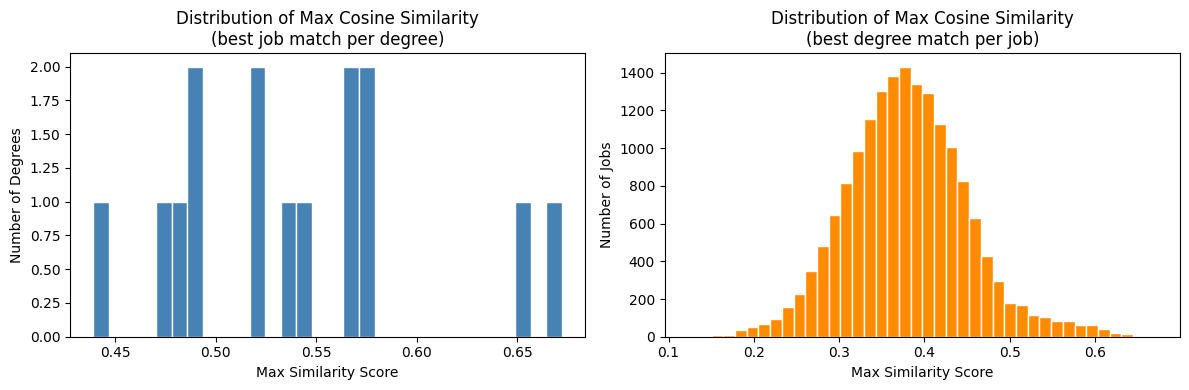

Degrees where best match > 0.5: 10 / 15


In [21]:
# Distribution of max similarity scores per degree (health check)
import matplotlib.pyplot as plt

max_sim_per_degree = sim_matrix.max(axis=1)
mean_sim_per_degree = sim_matrix.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_sim_per_degree, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Max Cosine Similarity\n(best job match per degree)')
axes[0].set_xlabel('Max Similarity Score')
axes[0].set_ylabel('Number of Degrees')

axes[1].hist(sim_matrix.max(axis=0), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Max Cosine Similarity\n(best degree match per job)')
axes[1].set_xlabel('Max Similarity Score')
axes[1].set_ylabel('Number of Jobs')

plt.tight_layout()
plt.savefig(CACHE_DIR / 'similarity_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Degrees where best match > 0.5: {(max_sim_per_degree > 0.5).sum()} / {len(degree_profiles)}')

---
## Section 5: Job-Skill Coverage Score (Hybrid Alignment)

We complement semantic similarity with an explicit job-skill coverage signal. The structured `skills[]` field in job ads provides a clean skill vocabulary. We match this against degree profile text lexically and score how much of each job's tagged skill set is covered.

In [22]:
# Build a global skill vocabulary from all job ads
skill_doc_freq: dict[str, int] = {}
skill_source = jobs['skills_clean'] if 'skills_clean' in jobs.columns else jobs['skills']

for skill_list in skill_source:
    cleaned_skills = set(clean_skill_list(skill_list))
    for skill in cleaned_skills:
        skill_doc_freq[skill] = skill_doc_freq.get(skill, 0) + 1

allowed_skills = {
    skill
    for skill, doc_freq in skill_doc_freq.items()
    if is_informative_skill(skill, doc_freq=doc_freq, total_docs=len(jobs))
}

jobs['skills_clean'] = jobs['skills'].apply(lambda values: clean_skill_list(values, allowed_skills))
skill_vocab = sorted(allowed_skills, key=len, reverse=True)

print(f'Unique skills after filtering: {len(skill_vocab):,}')
print(f'Removed low-information or overly common skills: {len(skill_doc_freq) - len(skill_vocab):,}')
print('Sample skills:', skill_vocab[:20])

Unique skills after filtering: 8,966
Removed low-information or overly common skills: 16
Sample skills: ['electrical engineering (including power engineerin', 'geriatrics, specialist qualification (physician)', 'process unit and utilities operations management', 'continuous integration and continuous deployment', 'user interface and user experience optimisation', 'workplace safety and health culture development', 'import and export documentation administration', 'learning and development programmes management', 'site and factory acceptance testing management', 'children with speech and language difficulties', 'food and beverage quality audit and assessment', 'order processing and change request management', 'food and beverage safety, hygiene and security', 'container loading and unloading administration', 'electrical and electronic systems maintenance', 'compliance with health and safety regulations', 'robotic and automation technology application', 'learning and development framework 

In [23]:
def extract_skills_from_text(text: str, vocab: list[str]) -> set[str]:
    """Find which skills from vocab appear (case-insensitive, whole-word)."""
    text_lower = str(text).lower()
    found = set()

    for skill in vocab:
        pattern = r'\b' + re.escape(skill.lower()) + r'\b'
        if re.search(pattern, text_lower):
            found.add(skill)

    return found


def job_skill_coverage(degree_skills: set, job_skills: set) -> float:
    if not job_skills:
        return 0.0
    return len(degree_skills & job_skills) / len(job_skills)


print('Extracting skills from degree profiles...')
DEGREE_SKILLS_CACHE = CACHE_DIR / f'degree_skills_actual_degrees_{SKILL_SIGNAL_VERSION}.json'

expected_ids = set(degree_profiles['degree_key'].astype(str))
degree_skills = {}
rebuild_cache = True

if DEGREE_SKILLS_CACHE.exists():
    with open(DEGREE_SKILLS_CACHE, 'r') as f:
        degree_skills_raw = json.load(f)

    cached_keys = set(degree_skills_raw.keys())

    if cached_keys == expected_ids:
        degree_skills = {k: set(v) for k, v in degree_skills_raw.items()}
        rebuild_cache = False
        print('Loaded from cache.')
    else:
        print('Cache keys do not match current degree_ids; rebuilding cache...')

if rebuild_cache:
    degree_skills = {}
    for _, row in tqdm(
        degree_profiles.iterrows(),
        total=len(degree_profiles),
        desc='Degree skill extraction'
    ):
        degree_key = str(row['degree_key'])
        degree_skills[degree_key] = extract_skills_from_text(row['profile_text'], skill_vocab)

    with open(DEGREE_SKILLS_CACHE, 'w') as f:
        json.dump({k: sorted(v) for k, v in degree_skills.items()}, f, indent=2)

    print(f'Cached degree skills to: {DEGREE_SKILLS_CACHE}')

# Show skills found for CS
cs_row = degree_profiles[degree_profiles['degree_id'] == 'cs']

if not cs_row.empty:
    degree_id = cs_row.iloc[0]['degree_key']
    degree_name = cs_row.iloc[0]['degree_name']
    print(f'\nSkills found in {degree_name} ({degree_id}):')
    print(sorted(degree_skills.get(degree_id, set()))[:30])
else:
    print('CS degree not found in degree_profiles.')

Extracting skills from degree profiles...


Degree skill extraction:   0%|          | 0/15 [00:00<?, ?it/s]

Cached degree skills to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_skills_actual_degrees_job_skill_coverage_v2.json

Skills found in Computer Science (cs::computer_science):
['algebra', 'algorithm design', 'algorithms', 'architecture', 'artificial intelligence', 'artistic', 'asian culture', 'assembly', 'authentication', 'automation', 'autonomous', 'calculus', 'categorical data analysis', 'circuit design', 'composition', 'computer science', 'computing', 'confidentiality', 'courses', 'critical thinking', 'culture', 'data', 'data analysis', 'data cleaning', 'data collection', 'data structures', 'debugging', 'deep learning', 'design', 'designed']


In [24]:
print(list(degree_skills.keys())[:10])

['acc::accounting', 'archi::architecture', 'biz::business_administration', 'bza::business_analytics', 'ce::civil_engineering', 'chem_eng::chemical_engineering', 'cnm::communications_and_new_media', 'cs::computer_science', 'dsa::data_science_and_analytics', 'dse::data_science_and_economics']


In [25]:
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
print(f'Skill coverage cache: {SKILL_COVERAGE_CACHE}')


Skill coverage cache: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\skill_coverage_matrix_targeted_dedup_v3_job_skill_coverage_v2.npy


In [26]:
# Job-skill coverage for each job's skill set against each degree's extracted skills
# Shape: (n_degrees × n_jobs)
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
expected_shape = (len(degree_profiles), len(jobs))

rebuild_skill_coverage = True
if SKILL_COVERAGE_CACHE.exists():
    cached_skill_coverage = np.load(SKILL_COVERAGE_CACHE)
    if cached_skill_coverage.shape == expected_shape:
        print('Loading job-skill coverage matrix from cache...')
        skill_coverage_matrix = cached_skill_coverage
        rebuild_skill_coverage = False
    else:
        print('Cached skill coverage matrix does not match the current degree/job corpus; rebuilding...')

if rebuild_skill_coverage:
    print('Computing job-skill coverage matrix...')
    n_deg = len(degree_profiles)
    n_job = len(jobs)
    skill_coverage_matrix = np.zeros((n_deg, n_job), dtype=np.float32)

    # Pre-convert filtered job skills to list-of-sets for speed
    allowed_skill_set = set(skill_vocab)
    job_skill_source = jobs['skills_clean'] if 'skills_clean' in jobs.columns else jobs['skills']
    job_skill_sets = [
        set(clean_skill_list(row, allowed_skill_set))
        for row in job_skill_source.tolist()
    ]

    for d_idx, (_, d_row) in enumerate(tqdm(degree_profiles.iterrows(), total=n_deg, desc='Job-skill coverage')):
        d_skills = degree_skills.get(d_row['degree_key'], set())
        if not d_skills:
            continue
        for j_idx, j_skills in enumerate(job_skill_sets):
            skill_coverage_matrix[d_idx, j_idx] = job_skill_coverage(d_skills, j_skills)

    np.save(SKILL_COVERAGE_CACHE, skill_coverage_matrix)
    print(f'Saved skill coverage matrix → {SKILL_COVERAGE_CACHE}')

print(f'Skill coverage matrix shape: {skill_coverage_matrix.shape}')
print(f'Non-zero entries: {(skill_coverage_matrix > 0).sum():,}')


Computing job-skill coverage matrix...


Job-skill coverage:   0%|          | 0/15 [00:00<?, ?it/s]

Saved skill coverage matrix → C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\skill_coverage_matrix_targeted_dedup_v3_job_skill_coverage_v2.npy
Skill coverage matrix shape: (15, 17096)
Non-zero entries: 87,816


In [27]:
# Hybrid alignment score: weighted combination
ALPHA = 0.7  # weight for semantic similarity
BETA  = 0.3  # weight for job-skill coverage

if sim_matrix.shape != skill_coverage_matrix.shape:
    raise ValueError(
        f'sim_matrix shape {sim_matrix.shape} does not match skill_coverage_matrix shape {skill_coverage_matrix.shape}. '
        'Re-run Sections 3-5 so both matrices are rebuilt from the same degree/job corpus.'
    )

hybrid_matrix = ALPHA * sim_matrix + BETA * skill_coverage_matrix
print(f'Hybrid score matrix shape: {hybrid_matrix.shape}')
print(f'Score range: [{hybrid_matrix.min():.4f}, {hybrid_matrix.max():.4f}]')

def top_k_jobs_hybrid(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return top-k jobs by hybrid alignment score for a given degree."""
    scores = hybrid_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'        : range(1, k+1),
        'job_id'      : jobs.iloc[top_idx]['job_id'].values,
        'job_title'   : jobs.iloc[top_idx]['title'].values,
        'categories'  : jobs.iloc[top_idx]['categories_str'].values,
        'cosine_sim'  : sim_matrix[degree_idx, top_idx].round(4),
        'skill_coverage': skill_coverage_matrix[degree_idx, top_idx].round(4),
        'hybrid_score': scores[top_idx].round(4),
    })

Hybrid score matrix shape: (15, 17096)
Score range: [-0.0032, 0.6654]


In [28]:
# Compare baseline vs hybrid for Computer Science
cs_idx = degree_profiles[degree_profiles['degree_id'] == 'cs'].index

if len(cs_idx) > 0:
    idx = degree_profiles.index.get_loc(cs_idx[0])
    degree_name = degree_profiles.iloc[idx]['degree_name']
    print(f'=== Hybrid Top-{K} for {degree_name} (cs) ===')
    display(top_k_jobs_hybrid(idx, K))
else:
    print('No CS degree found — showing first degree profile instead.')
    display(top_k_jobs_hybrid(0, K))

=== Hybrid Top-10 for Computer Science (cs) ===


,rank,job_id,job_title,categories,cosine_sim,skill_coverage,hybrid_score
0,1,MCF-2025-1801982,Software Engineer (Precision / Automation),"Engineering, Information Technology, Manufactu...",0.4866,0.3333,0.4406
1,2,MCF-2025-1801975,Software Engineer (Semiconductor Industry),"Engineering, Information Technology, Manufactu...",0.4783,0.3333,0.4348
2,3,MCF-2026-0184617,"Research Assistant, School of Computing",Sciences / Laboratory / R&D,0.3991,0.5000,0.4294
3,4,MCF-2025-1390895,"Staff Software Engineer, Applied AI, Google De...",Information Technology,0.3102,0.7000,0.4271
4,5,MCF-2025-1787631,Software Engineer,"Engineering, Information Technology",0.3905,0.5000,0.4234
5,6,MCF-2026-0180974,"Software Engineer, Applied AI, Google DeepMind",Information Technology,0.3106,0.6000,0.3974
6,7,MCF-2026-0188112,"Software Senior /Engineer (C#,PLC)- Automated ...","Engineering, Sciences / Laboratory / R&D",0.4602,0.2308,0.3914
7,8,MCF-2026-0188162,Calypso Developer (Contract),Information Technology,0.4285,0.3000,0.3899
8,9,MCF-2026-0159945,Junior Software Engineer,"Engineering, Information Technology, Manufactu...",0.4460,0.2500,0.3872
9,10,MCF-2026-0187901,Junior Software Engineer (Bank) l 12-month con...,Information Technology,0.4451,0.2500,0.3866


In [29]:
# For Section 8:
HYBRID_MATRIX_CACHE = CACHE_DIR / f'hybrid_matrix_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
np.save(HYBRID_MATRIX_CACHE, hybrid_matrix)
print(f'Saved hybrid matrix to: {HYBRID_MATRIX_CACHE}')


Saved hybrid matrix to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\hybrid_matrix_targeted_dedup_v3_module_top5_job120_v2_job_skill_coverage_v2.npy


---
## Section 6: Job Clustering (Scalability Layer)

Clustering the filtered, deduplicated in-scope job ads into role-level groups reduces sensitivity to firm-specific wording and provides MOE with a cleaner **degree ↔ job role category** view.


In [30]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer

N_CLUSTERS = 75  # adjust based on corpus size; 50–100 is a sensible range
CLUSTER_CACHE = CACHE_DIR / f'job_clusters_k{N_CLUSTERS}_{JOB_CORPUS_VERSION}.npy'

rebuild_clusters = True
if CLUSTER_CACHE.exists():
    cached_cluster_labels = np.load(CLUSTER_CACHE)
    if cached_cluster_labels.shape[0] == len(jobs):
        print('Loading cluster labels from cache...')
        cluster_labels = cached_cluster_labels
        rebuild_clusters = False
    else:
        print('Cached cluster labels do not match the current filtered job corpus; rebuilding...')

if rebuild_clusters:
    print(f'Clustering {len(jobs):,} jobs into {N_CLUSTERS} clusters...')
    t0 = time.time()
    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        batch_size=2048,
        n_init=5,
        max_iter=300,
    )
    cluster_labels = kmeans.fit_predict(job_embeddings)
    np.save(CLUSTER_CACHE, cluster_labels)
    print(f'Done in {time.time()-t0:.1f}s — inertia: {kmeans.inertia_:.1f}')

jobs['cluster_id'] = cluster_labels
print('Cluster size distribution:')
print(jobs['cluster_id'].value_counts().describe().round(0))


Clustering 17,096 jobs into 75 clusters...
Done in 10.9s — inertia: 7420.3
Cluster size distribution:
count     75.0
mean     228.0
std      102.0
min        1.0
25%      158.0
50%      221.0
75%      278.0
max      557.0
Name: count, dtype: float64


In [31]:
# Label each cluster with its top TF-IDF terms and most common MCF category
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english', min_df=2)
tfidf.fit(jobs['description_clean'].tolist())
feature_names = np.array(tfidf.get_feature_names_out())

cluster_info = []
for c in range(N_CLUSTERS):
    mask = jobs['cluster_id'] == c
    cluster_jobs = jobs[mask]
    n = mask.sum()

    # Top TF-IDF terms
    vecs = tfidf.transform(cluster_jobs['description_clean'].tolist())
    mean_tfidf = np.asarray(vecs.mean(axis=0)).flatten()
    top_term_idx = mean_tfidf.argsort()[::-1][:8]
    top_terms = ', '.join(feature_names[top_term_idx])

    # Most common MCF category
    all_cats = [c for cats in cluster_jobs['categories'].tolist() for c in (cats if isinstance(cats, list) else [])]
    top_cat = pd.Series(all_cats).value_counts().index[0] if all_cats else 'Unknown'

    # Most common title words
    title_words = pd.Series(' '.join(cluster_jobs['title'].tolist()).lower().split()).value_counts()
    common_title = ', '.join(title_words.head(5).index.tolist())

    cluster_info.append({
        'cluster_id'   : c,
        'n_jobs'       : n,
        'top_category' : top_cat,
        'top_terms'    : top_terms,
        'common_titles': common_title,
    })

cluster_df = pd.DataFrame(cluster_info).sort_values('n_jobs', ascending=False)
print('Top 20 clusters by size:')
display(cluster_df.head(20))

Top 20 clusters by size:


,cluster_id,n_jobs,top_category,top_terms,common_titles
5,5,557,F&B,"food, kitchen, chef, restaurant, hygiene, safe...","chef, cook, manager, assistant, kitchen"
29,29,443,Admin / Secretarial,"administrative, office, support, filing, docum...","admin, assistant, executive, administrative, a..."
59,59,441,Sales / Retail,"marketing, face, ll, career, growth, sales, te...","marketing, sales, &, and, events"
45,45,438,F&B,"food, service, restaurant, kitchen, customer, ...","service, crew, |, manager, /"
49,49,428,Accounting / Auditing / Taxation,"accounting, accounts, financial, invoices, ap,...","accounts, executive, assistant, -, admin"
1,1,412,Accounting / Auditing / Taxation,"accounting, audit, financial, tax, finance, ac...","finance, manager, accountant, audit, executive"
31,31,390,Building and Construction,"project, site, construction, ensure, safety, m...","project, manager, supervisor, construction, site"
10,10,365,Marketing / Public Relations,"marketing, media, content, digital, social, so...","marketing, executive, manager, &, digital"
54,54,331,Logistics / Supply Chain,"driving, vehicle, class, driver, delivery, goo...","driver, class, delivery, 3, |"
23,23,328,Admin / Secretarial,"salary, working, location, days, hours, job, o...","|, -, to, admin, up"


In [32]:
# Compute degree-to-cluster alignment matrix using cluster centroids
# Centroid = mean of unit-norm embeddings → re-normalise for cosine sim

cluster_centroids = np.zeros((N_CLUSTERS, job_embeddings.shape[1]), dtype=np.float32)
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    if mask.sum() > 0:
        centroid = job_embeddings[mask].mean(axis=0)
        norm = np.linalg.norm(centroid)
        cluster_centroids[c] = centroid / norm if norm > 0 else centroid

# degree-cluster similarity: (n_degrees × n_clusters)
module_cluster_sim = module_embeddings @ cluster_centroids.T
degree_cluster_sim = np.zeros((len(degree_profiles), N_CLUSTERS), dtype=np.float32)

for d_idx, degree_key in enumerate(degree_profiles['degree_key'].tolist()):
    module_idx = degree_module_indices.get(degree_key, np.array([], dtype=int))
    degree_cluster_sim[d_idx] = aggregate_top_k_similarity(module_cluster_sim[module_idx], DEGREE_MODULE_TOP_K)

print(f'Degree-cluster similarity matrix: {degree_cluster_sim.shape}')

Degree-cluster similarity matrix: (15, 75)


In [33]:
# Build a labelled degree-cluster alignment table
cluster_label_map = dict(zip(cluster_df['cluster_id'], cluster_df['top_category']))
cluster_terms_map = dict(zip(cluster_df['cluster_id'], cluster_df['top_terms']))

alignment_rows = []

for d_idx, d_row in degree_profiles.iterrows():
    d_pos = degree_profiles.index.get_loc(d_idx)
    scores = degree_cluster_sim[d_pos]
    top_clusters = np.argsort(scores)[::-1][:5]

    for rank, c_id in enumerate(top_clusters, 1):
        alignment_rows.append({
            'degree_id'      : d_row['degree_id'],
            'degree'         : d_row['degree_name'],
            'rank'           : rank,
            'cluster_id'     : int(c_id),
            'cluster_label'  : cluster_label_map.get(int(c_id), f'Cluster {c_id}'),
            'cluster_terms'  : cluster_terms_map.get(int(c_id), ''),
            'sim_score'      : round(float(scores[c_id]), 4),
        })


alignment_table = pd.DataFrame(alignment_rows)
alignment_table.to_csv(CACHE_DIR / 'degree_cluster_alignment.csv', index=False)

print('Sample: top-3 cluster matches per degree')
display(alignment_table[alignment_table['rank'] <= 3])

Sample: top-3 cluster matches per degree


,degree_id,degree,rank,cluster_id,cluster_label,cluster_terms,sim_score
0,acc,Accounting,1,1,Accounting / Auditing / Taxation,"accounting, audit, financial, tax, finance, ac...",0.6566
1,acc,Accounting,2,49,Accounting / Auditing / Taxation,"accounting, accounts, financial, invoices, ap,...",0.6358
2,acc,Accounting,3,33,Banking and Finance,"banking, bank, credit, aml, risk, financial, c...",0.5706
5,archi,Architecture,1,16,Architecture / Interior Design,"design, drawings, project, interior, architect...",0.5751
6,archi,Architecture,2,13,Building and Construction,"project, site, construction, works, engineerin...",0.5084
7,archi,Architecture,3,6,Building and Construction,"construction, project, site, civil, structural...",0.5043
10,biz,Business Administration,1,40,Logistics / Supply Chain,"management, supply, business, customer, invent...",0.5473
11,biz,Business Administration,2,1,Accounting / Auditing / Taxation,"accounting, audit, financial, tax, finance, ac...",0.5375
12,biz,Business Administration,3,18,Banking and Finance,"investment, financial, wealth, client, clients...",0.5370
15,bza,Business Analytics,1,71,Banking and Finance,"business, risk, data, analysis, analyst, finan...",0.5082


In [34]:
# For Section 8:
CLUSTER_DF_CACHE = CACHE_DIR / f'cluster_df_{JOB_CORPUS_VERSION}.csv'
DEGREE_CLUSTER_SIM_CACHE = CACHE_DIR / f'degree_cluster_sim_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'

cluster_df.to_csv(CLUSTER_DF_CACHE, index=False)
np.save(DEGREE_CLUSTER_SIM_CACHE, degree_cluster_sim)
print(f'Saved cluster labels to: {CLUSTER_DF_CACHE}')
print(f'Saved degree-cluster similarity to: {DEGREE_CLUSTER_SIM_CACHE}')


Saved cluster labels to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\cluster_df_targeted_dedup_v3.csv
Saved degree-cluster similarity to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\degree_cluster_sim_targeted_dedup_v3_module_top5_job120_v2.npy


---
## Section 7: Gold Dataset and Evaluation

This section uses the project gold dataset stored in `notebooks/evaluation/gold_degree_job_alignment.csv` as the single evaluation source.

Every methodology is evaluated against the **same labelled degree-job pairs** so the comparison reflects alignment with human judgement rather than raw score scale alone.


### Notebook review summary

Key workflow fixes made in this notebook revision:

- Fixed a syntax error in the degree-module merge section so the notebook executes top to bottom.
- Made transformer loading lazy so cached embeddings can be reused without forcing a model download.
- Replaced the earlier manual placeholder evaluation with a shared framework that loads the project gold dataset directly.
- Standardised evaluation around the actual retrieval unit used in this notebook: **degree-profile to job** alignment.
- Deprecated the earlier standalone NDCG-only reporting and overlapping summary cells in favour of one consistent comparison table, plots, and agreement analysis.
- Evaluated the clustering layer as a **cluster-routed semantic ranker** so it can be compared fairly against other job-level retrieval methods.


In [35]:
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer

N_CLUSTERS = int(globals().get('N_CLUSTERS', 75))

DEGREE_META_CACHE = CACHE_DIR / 'degree_profiles.parquet'
JOB_META_CACHE = CACHE_DIR / f'jobs_clean_{JOB_CORPUS_VERSION}.parquet'
SIM_MATRIX_CACHE = CACHE_DIR / f'sim_matrix_{MODEL_NAME.replace("/","_")}_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
SKILL_COVERAGE_CACHE = CACHE_DIR / f'skill_coverage_matrix_{JOB_CORPUS_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
HYBRID_MATRIX_CACHE = CACHE_DIR / f'hybrid_matrix_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}_{SKILL_SIGNAL_VERSION}.npy'
CLUSTER_CACHE = CACHE_DIR / f'job_clusters_k{N_CLUSTERS}_{JOB_CORPUS_VERSION}.npy'
DEGREE_CLUSTER_SIM_CACHE = CACHE_DIR / f'degree_cluster_sim_{JOB_CORPUS_VERSION}_{SEMANTIC_RETRIEVAL_VERSION}.npy'
LEXICAL_MATRIX_CACHE = CACHE_DIR / f'lexical_tfidf_matrix_{JOB_CORPUS_VERSION}.npy'
GOLD_DATASET_PATH = EVAL_DIR / 'gold_degree_job_alignment.csv'
METHOD_METRICS_PATH = EVAL_DIR / 'method_metrics.csv'
METHOD_QUERY_METRICS_PATH = EVAL_DIR / 'method_query_metrics.csv'

# Reload cached artefacts when running the notebook from this section after a restart.
if 'degree_profiles' not in globals():
    degree_profiles = pd.read_parquet(DEGREE_META_CACHE)
if 'jobs' not in globals():
    jobs = pd.read_parquet(JOB_META_CACHE)
if 'sim_matrix' not in globals():
    sim_matrix = np.load(SIM_MATRIX_CACHE)
if 'skill_coverage_matrix' not in globals():
    skill_coverage_matrix = np.load(SKILL_COVERAGE_CACHE)
if 'hybrid_matrix' not in globals():
    hybrid_matrix = np.load(HYBRID_MATRIX_CACHE)
if 'degree_cluster_sim' not in globals():
    degree_cluster_sim = np.load(DEGREE_CLUSTER_SIM_CACHE)
if 'cluster_labels' not in globals():
    cluster_labels = np.load(CLUSTER_CACHE)

jobs = jobs.copy()
degree_profiles = degree_profiles.copy()

if 'job_text' not in jobs.columns:
    jobs['job_text'] = jobs.apply(build_structured_job_text, axis=1)

jobs['cluster_id'] = np.asarray(cluster_labels, dtype=int)

expected_shape = (len(degree_profiles), len(jobs))
for name, matrix in {
    'sim_matrix': sim_matrix,
    'skill_coverage_matrix': skill_coverage_matrix,
    'hybrid_matrix': hybrid_matrix,
}.items():
    if matrix.shape != expected_shape:
        raise ValueError(f'{name} has shape {matrix.shape}, expected {expected_shape}. Re-run the upstream sections.')

if degree_cluster_sim.shape[0] != len(degree_profiles):
    raise ValueError('degree_cluster_sim does not match current degree_profiles. Re-run Section 6.')

if LEXICAL_MATRIX_CACHE.exists():
    lexical_matrix = np.load(LEXICAL_MATRIX_CACHE)
    if lexical_matrix.shape != expected_shape:
        lexical_matrix = None
else:
    lexical_matrix = None

if lexical_matrix is None:
    print('Building lexical TF-IDF baseline matrix...')
    lexical_vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_features=30000,
    )
    corpus = degree_profiles['profile_text'].tolist() + jobs['job_text'].tolist()
    lexical_vectorizer.fit(corpus)
    degree_tfidf = lexical_vectorizer.transform(degree_profiles['profile_text'].tolist())
    job_tfidf = lexical_vectorizer.transform(jobs['job_text'].tolist())
    lexical_matrix = (degree_tfidf @ job_tfidf.T).toarray().astype(np.float32)
    np.save(LEXICAL_MATRIX_CACHE, lexical_matrix)
    print(f'Saved lexical baseline to: {LEXICAL_MATRIX_CACHE}')
else:
    print(f'Loaded lexical baseline from: {LEXICAL_MATRIX_CACHE}')

cluster_prior_matrix = degree_cluster_sim[:, jobs['cluster_id'].to_numpy()]
cluster_routed_matrix = (0.65 * cluster_prior_matrix + 0.35 * sim_matrix).astype(np.float32)


def slugify(text: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', text.lower()).strip('_')


method_score_matrices = {
    'Lexical TF-IDF': lexical_matrix,
    'Semantic cosine': sim_matrix,
    'Skill coverage': skill_coverage_matrix,
    'Hybrid semantic + skill': hybrid_matrix,
    'Cluster-routed semantic': cluster_routed_matrix,
}

method_notes = {
    'Lexical TF-IDF': 'Sparse lexical baseline over curriculum and job text.',
    'Semantic cosine': f'Degree-to-job cosine using top-{DEGREE_MODULE_TOP_K} module similarities.',
    'Skill coverage': 'Exact overlap between extracted degree skills and tagged job skills.',
    'Hybrid semantic + skill': f'Weighted blend with alpha={ALPHA:.1f}, beta={BETA:.1f}.',
    'Cluster-routed semantic': 'Cluster prior from Section 6 combined with semantic job scores.',
}

def normalise_text(value) -> str:
    return '' if pd.isna(value) else str(value).strip()


degree_profiles['degree_lookup_id'] = degree_profiles['degree_id'].map(normalise_text)
degree_profiles['degree_lookup_name'] = degree_profiles['degree_name'].map(normalise_text)
jobs['job_lookup_id'] = jobs['job_id'].map(normalise_text)

degree_pair_index = {
    (row.degree_lookup_id, row.degree_lookup_name): idx
    for idx, row in enumerate(degree_profiles[['degree_lookup_id', 'degree_lookup_name']].itertuples(index=False))
}
degree_id_index = degree_profiles.groupby('degree_lookup_id').indices
degree_name_index = degree_profiles.groupby('degree_lookup_name').indices
job_index = {job_id: idx for idx, job_id in enumerate(jobs['job_lookup_id'])}


def resolve_degree_profile_idx(degree_id: str, degree_name: str):
    degree_id = normalise_text(degree_id)
    degree_name = normalise_text(degree_name)
    pair_key = (degree_id, degree_name)
    if pair_key in degree_pair_index:
        return int(degree_pair_index[pair_key])

    id_matches = degree_id_index.get(degree_id, [])
    if len(id_matches) == 1:
        return int(id_matches[0])

    name_matches = degree_name_index.get(degree_name, [])
    if len(name_matches) == 1:
        return int(name_matches[0])

    return None

print('Methods available for evaluation:')
for method_name in method_score_matrices:
    print(f'  - {method_name}')


Building lexical TF-IDF baseline matrix...
Saved lexical baseline to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\cache\lexical_tfidf_matrix_targeted_dedup_v3.npy
Methods available for evaluation:
  - Lexical TF-IDF
  - Semantic cosine
  - Skill coverage
  - Hybrid semantic + skill
  - Cluster-routed semantic


### 7a - Gold Dataset Loading

The notebook now loads the project gold dataset directly from `notebooks/evaluation/gold_degree_job_alignment.csv`.

Expected labels:

- `Relevant = 2`
- `Somewhat Relevant = 1`
- `Not Relevant = 0`

Any extra provenance columns in the CSV are ignored for evaluation so the notebook focuses on the final human judgement labels.


In [36]:
LABEL_TO_SCORE = {
    'Relevant': 2,
    'Somewhat Relevant': 1,
    'Not Relevant': 0,
}
SCORE_TO_LABEL = {score: label for label, score in LABEL_TO_SCORE.items()}

if not GOLD_DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Gold dataset not found at {GOLD_DATASET_PATH}. Place gold_degree_job_alignment.csv in notebooks/evaluation.'
    )


def standardise_gold_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if 'degree_id' not in df.columns and 'curriculum_id' in df.columns:
        df['degree_id'] = df['curriculum_id']
    if 'degree_name' not in df.columns and 'curriculum_title' in df.columns:
        df['degree_name'] = df['curriculum_title']

    if 'human_relevance_score' not in df.columns:
        if 'human_label' not in df.columns:
            raise ValueError('Gold dataset must contain either human_relevance_score or human_label.')
        raw_labels = df['human_label'].astype(str).str.strip().str.lower()
        df['human_relevance_score'] = raw_labels.map({
            '2': 2,
            '1': 1,
            '0': 0,
            'relevant': 2,
            'somewhat relevant': 1,
            'not relevant': 0,
        })

    df['human_relevance_score'] = pd.to_numeric(df['human_relevance_score'], errors='coerce')
    df = df[df['human_relevance_score'].isin([0, 1, 2])].copy()
    df['human_relevance_score'] = df['human_relevance_score'].astype(int)
    df['human_label'] = df['human_relevance_score'].map(SCORE_TO_LABEL)
    df['degree_id'] = df['degree_id'].map(normalise_text)
    df['degree_name'] = df['degree_name'].map(normalise_text)
    df['job_id'] = df['job_id'].map(normalise_text)

    if 'query_id' not in df.columns:
        df['query_id'] = df['degree_id']
    if 'curriculum_id' not in df.columns:
        df['curriculum_id'] = df['degree_id']
    if 'curriculum_title' not in df.columns:
        df['curriculum_title'] = df['degree_name']
    if 'job_title' not in df.columns:
        df = df.merge(jobs[['job_id', 'title']], on='job_id', how='left')
        df = df.rename(columns={'title': 'job_title'})

    keep_first_non_missing = {
        'job_categories': jobs[['job_id', 'categories_str']].rename(columns={'categories_str': 'job_categories'}),
        'job_text': jobs[['job_id', 'job_text']],
        'company': jobs[['job_id', 'company']],
    }
    for col, lookup in keep_first_non_missing.items():
        if col not in df.columns or df[col].isna().any():
            df = df.drop(columns=[col], errors='ignore').merge(lookup, on='job_id', how='left')

    return df


gold_raw_df = pd.read_csv(GOLD_DATASET_PATH)
gold_df = standardise_gold_dataset(gold_raw_df)
gold_df['degree_profile_idx'] = gold_df.apply(
    lambda row: resolve_degree_profile_idx(row['degree_id'], row['degree_name']),
    axis=1,
)
gold_df['job_lookup_id'] = gold_df['job_id'].map(normalise_text)
gold_df['job_idx'] = gold_df['job_lookup_id'].map(job_index)

gold_eval_df = gold_df[
    gold_df['degree_profile_idx'].notna() & gold_df['job_idx'].notna()
].copy()
gold_eval_df['degree_profile_idx'] = gold_eval_df['degree_profile_idx'].astype(int)
gold_eval_df['job_idx'] = gold_eval_df['job_idx'].astype(int)

skipped_gold_df = gold_df.loc[gold_df.index.difference(gold_eval_df.index)].copy()
if gold_eval_df.empty:
    raise ValueError('No gold rows could be matched to the current degree/job artefacts. Re-run the upstream sections.')

gold_preview_cols = [
    'degree_id', 'degree_name', 'job_id', 'job_title', 'human_label', 'human_relevance_score'
]
label_distribution = (
    gold_eval_df['human_label']
    .value_counts()
    .rename_axis('human_label')
    .reset_index(name='count')
)
gold_load_summary = pd.DataFrame([
    {
        'loaded_rows': len(gold_df),
        'matched_rows': len(gold_eval_df),
        'skipped_rows': len(skipped_gold_df),
        'matched_degrees': gold_eval_df[['degree_id', 'degree_name']].drop_duplicates().shape[0],
        'skipped_degrees': skipped_gold_df[['degree_id', 'degree_name']].drop_duplicates().shape[0],
    }
])

display(Markdown(f'**Loaded gold dataset:** `{GOLD_DATASET_PATH}`'))
display(gold_load_summary)
if not skipped_gold_df.empty:
    display(Markdown('**Skipped gold pairs (unmatched to current cached artefacts):**'))
    display(skipped_gold_df[['degree_id', 'degree_name']].drop_duplicates().sort_values(['degree_id', 'degree_name']))
display(label_distribution)
display(gold_eval_df[gold_preview_cols].head(10))


**Loaded gold dataset:** `C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\evaluation\gold_degree_job_alignment.csv`

,loaded_rows,matched_rows,skipped_rows,matched_degrees,skipped_degrees
0,260190,256350,3840,15,15


**Skipped gold pairs (unmatched to current cached artefacts):**

,degree_id,degree_name
302,acc,Accounting
17648,archi,Architecture
34994,biz,Business Administration
52340,bza,Business Analytics
69686,ce,Civil Engineering
87032,chem_eng,Chemical Engineering
104378,cnm,Communications and New Media
121724,cs,Computer Science
139070,dsa,Data Science and Analytics
156416,dse,Data Science and Economics


,human_label,count
0,Not Relevant,218852
1,Somewhat Relevant,26191
2,Relevant,11307


,degree_id,degree_name,job_id,job_title,human_label,human_relevance_score
0,acc,Accounting,MCF-2025-1137542,Installation Technician,Not Relevant,0
1,acc,Accounting,MCF-2025-1180493,Dental Clinic Assistant,Not Relevant,0
2,acc,Accounting,MCF-2025-1283465,SUPERVISOR,Not Relevant,0
3,acc,Accounting,MCF-2025-1324955,Sales Manager,Not Relevant,0
4,acc,Accounting,MCF-2025-1441969,Housekeeping Supervisor,Not Relevant,0
5,acc,Accounting,MCF-2025-1451549,PROCUREMENT CUM QUANTITY SURVEYOR,Not Relevant,0
6,acc,Accounting,MCF-2025-1462264,PLATING MAINTENANCE TECHNICIAN,Not Relevant,0
7,acc,Accounting,MCF-2025-1506743,FIELD ENGINEER,Not Relevant,0
8,acc,Accounting,MCF-2025-1550687,Site & Operations Coordinator – Construction E...,Not Relevant,0
9,acc,Accounting,MCF-2025-1569420,Senior Technical,Not Relevant,0


### 7b - Metric Definitions and Consistent Method Comparison

The comparison below evaluates each method on the **same gold-labelled degree-job pairs**.

Metrics:

- `Precision@k` (strict): fraction of the top-`k` jobs labelled **Relevant (2)**.
- `RelaxedPrecision@k`: fraction of the top-`k` jobs labelled **Relevant or Somewhat Relevant (>=1)**.
- `HitRate@k` (strict): whether at least one **Relevant (2)** job appears in the top-`k`.
- `RelaxedHitRate@k`: whether at least one job with score `>=1` appears in the top-`k`.
- `NDCG@k`: a graded-ranking metric that rewards placing `Relevant (2)` and `Somewhat Relevant (1)` jobs near the top of the list.
- `Balanced pairwise agreement`: for each degree, checks whether jobs with a higher human label also receive a higher model score, then averages equally over `2>1`, `2>0`, and `1>0` comparisons.
- `Human-model agreement`: mean **query-wise Spearman rank correlation** between model scores and gold relevance scores. It is retained here as a secondary diagnostic, but it is not the primary ranking metric because the dataset has coarse `0/1/2` labels, many ties, and strong class imbalance.


In [37]:
def precision_at_k(labels: list[int], k: int, threshold: int = 2) -> float:
    top_labels = labels[:k]
    if not top_labels:
        return 0.0
    return float(np.mean([label >= threshold for label in top_labels]))


def hit_rate_at_k(labels: list[int], k: int, threshold: int = 2) -> float:
    top_labels = labels[:k]
    if not top_labels:
        return 0.0
    return float(any(label >= threshold for label in top_labels))


def dcg_at_k(labels: list[int] | np.ndarray, k: int) -> float:
    rel = np.asarray(labels[:k], dtype=float)
    if rel.size == 0:
        return 0.0
    gains = np.power(2.0, rel) - 1.0
    discounts = 1.0 / np.log2(np.arange(2, rel.size + 2))
    return float(np.sum(gains * discounts))


def ndcg_at_k(labels: list[int] | np.ndarray, k: int) -> float:
    rel = np.asarray(labels, dtype=float)
    if rel.size == 0:
        return 0.0
    actual = dcg_at_k(rel, k)
    ideal = dcg_at_k(np.sort(rel)[::-1], k)
    return float(actual / ideal) if ideal > 0 else np.nan


def ordered_pair_accuracy(higher_scores: np.ndarray, lower_scores: np.ndarray) -> float:
    higher_scores = np.asarray(higher_scores, dtype=float)
    lower_scores = np.asarray(lower_scores, dtype=float)
    if higher_scores.size == 0 or lower_scores.size == 0:
        return np.nan

    lower_sorted = np.sort(lower_scores)
    wins = np.searchsorted(lower_sorted, higher_scores, side='left')
    ties = np.searchsorted(lower_sorted, higher_scores, side='right') - wins
    total_pairs = higher_scores.size * lower_sorted.size
    return float((wins.sum() + 0.5 * ties.sum()) / total_pairs)


def balanced_pairwise_agreement(scores: np.ndarray, labels: np.ndarray) -> float:
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)

    pair_scores = []
    for higher_label, lower_label in [(2, 1), (2, 0), (1, 0)]:
        pair_score = ordered_pair_accuracy(
            scores[labels == higher_label],
            scores[labels == lower_label],
        )
        if pd.notna(pair_score):
            pair_scores.append(pair_score)

    return float(np.mean(pair_scores)) if pair_scores else np.nan


def safe_spearman(scores: np.ndarray, labels: np.ndarray) -> float:
    if len(scores) < 2:
        return np.nan
    if np.unique(scores).size < 2 or np.unique(labels).size < 2:
        return np.nan
    rho, _ = spearmanr(scores, labels)
    return float(rho) if pd.notna(rho) else np.nan


ks = (1, 3, 5)
query_metric_rows = []
comparison_rows = []

for method_name, score_matrix in method_score_matrices.items():
    per_query_rows = []
    combined_scores = []
    combined_labels = []

    for degree_profile_idx, grp in gold_eval_df.groupby('degree_profile_idx'):
        d_idx = int(degree_profile_idx)
        eval_grp = grp.copy()

        eval_grp['model_score'] = eval_grp['job_lookup_id'].map(
            lambda job_id: float(score_matrix[d_idx, job_index[job_id]])
        )
        eval_grp = eval_grp.sort_values('model_score', ascending=False).reset_index(drop=True)

        labels = eval_grp['human_relevance_score'].astype(int).tolist()
        scores = eval_grp['model_score'].to_numpy(dtype=float)
        gold_scores = eval_grp['human_relevance_score'].to_numpy(dtype=float)
        agreement = safe_spearman(scores, gold_scores)
        pairwise_agreement = balanced_pairwise_agreement(scores, gold_scores)

        row = {
            'degree_profile_idx': d_idx,
            'degree_id': eval_grp['degree_id'].iloc[0],
            'degree_name': eval_grp['degree_name'].iloc[0],
            'method': method_name,
            'gold_pairs': len(eval_grp),
            'Balanced pairwise agreement': pairwise_agreement,
            'Human-model agreement': agreement,
        }

        for k in ks:
            row[f'Precision@{k}'] = precision_at_k(labels, k, threshold=2)
            row[f'HitRate@{k}'] = hit_rate_at_k(labels, k, threshold=2)
            row[f'RelaxedPrecision@{k}'] = precision_at_k(labels, k, threshold=1)
            row[f'RelaxedHitRate@{k}'] = hit_rate_at_k(labels, k, threshold=1)
            row[f'NDCG@{k}'] = ndcg_at_k(labels, k)

        per_query_rows.append(row)
        combined_scores.extend(scores.tolist())
        combined_labels.extend(gold_scores.tolist())

    method_query_df = pd.DataFrame(per_query_rows)
    query_metric_rows.append(method_query_df)

    summary_row = {
        'Method': method_name,
        'Notes': method_notes[method_name],
        'GoldPairs': int(method_query_df['gold_pairs'].sum()) if not method_query_df.empty else 0,
        'Degrees': int(method_query_df['degree_profile_idx'].nunique()) if not method_query_df.empty else 0,
        'Global agreement': safe_spearman(np.asarray(combined_scores), np.asarray(combined_labels)),
    }

    for metric in [
        'Precision@1', 'Precision@3', 'Precision@5',
        'HitRate@1', 'HitRate@3', 'HitRate@5',
        'RelaxedPrecision@1', 'RelaxedPrecision@3', 'RelaxedPrecision@5',
        'RelaxedHitRate@1', 'RelaxedHitRate@3', 'RelaxedHitRate@5',
        'NDCG@1', 'NDCG@3', 'NDCG@5',
        'Balanced pairwise agreement',
        'Human-model agreement',
    ]:
        summary_row[metric] = float(method_query_df[metric].mean()) if metric in method_query_df else np.nan

    comparison_rows.append(summary_row)

query_metrics_df = pd.concat(query_metric_rows, ignore_index=True)
comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['Balanced pairwise agreement', 'NDCG@5', 'Precision@3'],
    ascending=False,
).reset_index(drop=True)

comparison_df.to_csv(METHOD_METRICS_PATH, index=False)
query_metrics_df.to_csv(METHOD_QUERY_METRICS_PATH, index=False)

strict_columns = [
    'Method', 'Precision@1', 'Precision@3', 'Precision@5',
    'HitRate@1', 'HitRate@3', 'HitRate@5',
    'Human-model agreement', 'Notes'
]
relaxed_columns = [
    'Method', 'RelaxedPrecision@1', 'RelaxedPrecision@3', 'RelaxedPrecision@5',
    'RelaxedHitRate@1', 'RelaxedHitRate@3', 'RelaxedHitRate@5'
]
ranking_columns = [
    'Method', 'NDCG@1', 'NDCG@3', 'NDCG@5',
    'Balanced pairwise agreement', 'Human-model agreement', 'Notes'
]

print(f'Saved method comparison to: {METHOD_METRICS_PATH}')
print(f'Saved query-level metrics to: {METHOD_QUERY_METRICS_PATH}')
display(comparison_df[strict_columns].round(3))
display(comparison_df[relaxed_columns].round(3))
display(comparison_df[ranking_columns].round(3))


Saved method comparison to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\evaluation\method_metrics.csv
Saved query-level metrics to: C:\Users\matth\OneDrive\Documents\DSA4264\Repo\DSA4264-Text-Group-3\notebooks\evaluation\method_query_metrics.csv


,Method,Precision@1,Precision@3,Precision@5,HitRate@1,HitRate@3,HitRate@5,Human-model agreement,Notes
0,Hybrid semantic + skill,0.733,0.711,0.680,0.733,0.800,0.867,0.310,"Weighted blend with alpha=0.7, beta=0.3."
1,Cluster-routed semantic,0.800,0.689,0.747,0.800,0.867,0.867,0.308,Cluster prior from Section 6 combined with sem...
2,Semantic cosine,0.800,0.644,0.693,0.800,0.800,0.867,0.297,Degree-to-job cosine using top-5 module simila...
3,Lexical TF-IDF,0.400,0.489,0.453,0.400,0.867,0.933,0.289,Sparse lexical baseline over curriculum and jo...
4,Skill coverage,0.333,0.244,0.280,0.333,0.333,0.533,0.213,Exact overlap between extracted degree skills ...


,Method,RelaxedPrecision@1,RelaxedPrecision@3,RelaxedPrecision@5,RelaxedHitRate@1,RelaxedHitRate@3,RelaxedHitRate@5
0,Hybrid semantic + skill,0.867,0.867,0.840,0.867,0.867,0.867
1,Cluster-routed semantic,0.933,0.867,0.880,0.933,0.933,1.000
2,Semantic cosine,0.867,0.844,0.840,0.867,0.933,0.933
3,Lexical TF-IDF,0.600,0.733,0.720,0.600,0.933,0.933
4,Skill coverage,0.533,0.489,0.467,0.533,0.600,0.733


### 7b.1 - Interpreting Agreement Relative to Its Ceiling

`Human-model agreement` is a full-list Spearman rank correlation, whereas `Precision@k`, `HitRate@k`, and `NDCG@k` focus on retrieval quality near the top of the ranked list.

Because each degree in this gold dataset contains large tied blocks of `Not Relevant`, `Somewhat Relevant`, and `Relevant` labels, the maximum attainable Spearman score is often well below `1.0`. The table below estimates that degree-specific ceiling by sorting each degree's labels into the best possible order and then reports each method's agreement as a share of that ceiling.

Ceiling-normalized Spearman is still useful as a diagnostic, but it is **not** the best primary metric here for three reasons:

- it still evaluates the **entire** labelled list rather than the top-ranked jobs that matter most in retrieval;
- it remains sensitive to coarse `0/1/2` labels and large tied blocks even after normalization;
- it gives equal weight to degree families with very different numbers of positive examples.

For that reason, this notebook now treats `NDCG@k` and `Balanced pairwise agreement` as the main retrieval-aligned agreement metrics, while ceiling-normalized Spearman is retained as a secondary interpretability check.


In [ ]:
def ideal_spearman_ceiling(labels: np.ndarray) -> float:
    labels = np.asarray(labels, dtype=float)
    if labels.size < 2 or np.unique(labels).size < 2:
        return np.nan

    ideal_scores = np.arange(labels.size, 0, -1, dtype=float)
    ideal_labels = np.sort(labels)[::-1]
    return safe_spearman(ideal_scores, ideal_labels)


degree_ceiling_df = (
    gold_eval_df
    .groupby(['degree_id', 'degree_name'])
    .agg(
        GoldPairs=('job_id', 'size'),
        Relevant=('human_relevance_score', lambda s: int((s == 2).sum())),
        SomewhatRelevant=('human_relevance_score', lambda s: int((s == 1).sum())),
        NotRelevant=('human_relevance_score', lambda s: int((s == 0).sum())),
        AgreementCeiling=('human_relevance_score', lambda s: ideal_spearman_ceiling(s.to_numpy())),
    )
    .reset_index()
)

query_with_ceiling_df = query_metrics_df.merge(
    degree_ceiling_df[['degree_id', 'degree_name', 'AgreementCeiling']],
    on=['degree_id', 'degree_name'],
    how='left',
)
query_with_ceiling_df['Ceiling-normalized agreement'] = np.where(
    query_with_ceiling_df['AgreementCeiling'] > 0,
    query_with_ceiling_df['Human-model agreement'] / query_with_ceiling_df['AgreementCeiling'],
    np.nan,
)

agreement_ceiling_summary_df = (
    comparison_df[['Method', 'NDCG@5', 'Balanced pairwise agreement', 'Human-model agreement']]
    .merge(
        query_with_ceiling_df
        .groupby('method')
        .agg(
            MeanAgreementCeiling=('AgreementCeiling', 'mean'),
            MeanCeilingNormalizedAgreement=('Ceiling-normalized agreement', 'mean'),
            MedianCeilingNormalizedAgreement=('Ceiling-normalized agreement', 'median'),
        )
        .reset_index()
        .rename(columns={'method': 'Method'}),
        on='Method',
        how='left',
    )
    .sort_values('Balanced pairwise agreement', ascending=False)
    .reset_index(drop=True)
)

degree_ceiling_reference_df = (
    degree_ceiling_df[
        [
            'degree_id',
            'degree_name',
            'Relevant',
            'SomewhatRelevant',
            'NotRelevant',
            'AgreementCeiling',
        ]
    ]
    .sort_values('AgreementCeiling')
    .reset_index(drop=True)
)

display(Markdown('**Ceiling-normalized human-model agreement by method**'))
display(agreement_ceiling_summary_df.round(3))

display(Markdown('**Degree-specific agreement ceiling reference**'))
display(degree_ceiling_reference_df.round(3))


### 7c - Plots and Diagnostic Tables

The charts below focus on the project objective: **which matching methodology aligns most closely with the reference labels**.


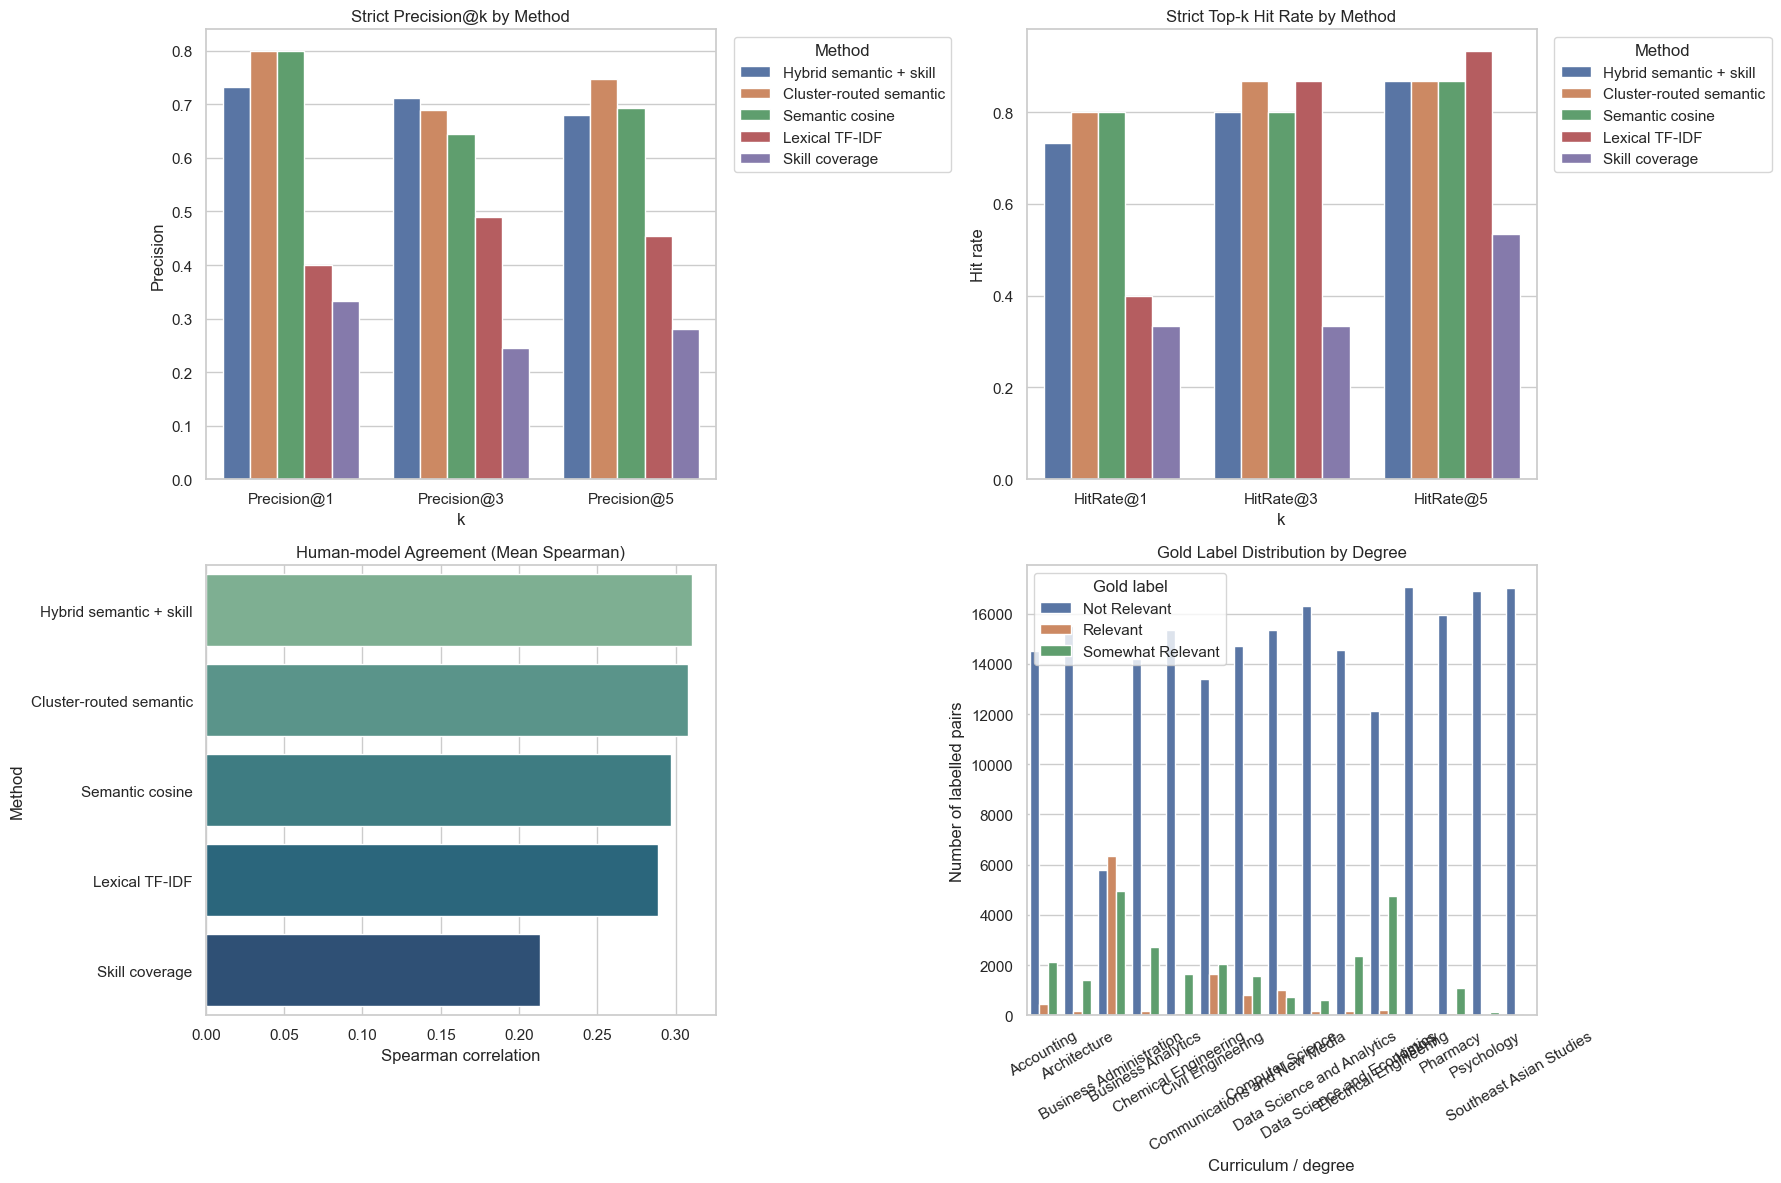

In [38]:
sns.set_theme(style='whitegrid', context='notebook')

precision_plot_df = comparison_df.melt(
    id_vars=['Method'],
    value_vars=['Precision@1', 'Precision@3', 'Precision@5'],
    var_name='Metric',
    value_name='Score',
)

hitrate_plot_df = comparison_df.melt(
    id_vars=['Method'],
    value_vars=['HitRate@1', 'HitRate@3', 'HitRate@5'],
    var_name='Metric',
    value_name='Score',
)

agreement_plot_df = comparison_df[['Method', 'Balanced pairwise agreement']].copy()
label_plot_df = (
    gold_eval_df.groupby(['degree_name', 'human_label'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=precision_plot_df, x='Metric', y='Score', hue='Method', ax=axes[0, 0])
axes[0, 0].set_title('Strict Precision@k by Method')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=hitrate_plot_df, x='Metric', y='Score', hue='Method', ax=axes[0, 1])
axes[0, 1].set_title('Strict Top-k Hit Rate by Method')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Hit rate')
axes[0, 1].legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.barplot(data=agreement_plot_df, x='Balanced pairwise agreement', y='Method', palette='crest', ax=axes[1, 0])
axes[1, 0].set_title('Balanced Pairwise Agreement by Method')
axes[1, 0].set_xlabel('Pairwise agreement')
axes[1, 0].set_ylabel('Method')

sns.barplot(data=label_plot_df, x='degree_name', y='count', hue='human_label', ax=axes[1, 1])
axes[1, 1].set_title('Gold Label Distribution by Degree')
axes[1, 1].set_xlabel('Curriculum / degree')
axes[1, 1].set_ylabel('Number of labelled pairs')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(title='Gold label')

plt.tight_layout()
plt.show()


---
## Section 8: Interpretation and Final Takeaway

This final section summarises which methodology aligns best with the loaded gold dataset and what the remaining methodological caveats are.


In [39]:
agreement_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='Human-model agreement',
        aggfunc='mean',
    )
    .round(3)
)

precision_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='Precision@3',
        aggfunc='mean',
    )
    .round(3)
)

ndcg_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='NDCG@5',
        aggfunc='mean',
    )
    .round(3)
)

pairwise_by_degree = (
    query_metrics_df
    .pivot_table(
        index=['degree_id', 'degree_name'],
        columns='method',
        values='Balanced pairwise agreement',
        aggfunc='mean',
    )
    .round(3)
)

print('Query-wise agreement by degree')
display(agreement_by_degree)

print('Query-wise Precision@3 by degree')
display(precision_by_degree)

print('Query-wise NDCG@5 by degree')
display(ndcg_by_degree)

print('Query-wise balanced pairwise agreement by degree')
display(pairwise_by_degree)


Query-wise agreement by degree


,method,Cluster-routed semantic,Hybrid semantic + skill,Lexical TF-IDF,Semantic cosine,Skill coverage
degree_id,degree_name,,,,,
acc,Accounting,0.350,0.410,0.390,0.362,0.405
archi,Architecture,0.408,0.424,0.369,0.416,0.302
biz,Business Administration,0.543,0.551,0.477,0.538,0.325
bza,Business Analytics,0.276,0.263,0.204,0.269,0.067
ce,Civil Engineering,0.454,0.473,0.370,0.449,0.286
chem_eng,Chemical Engineering,0.288,0.286,0.260,0.287,0.152
cnm,Communications and New Media,0.369,0.388,0.410,0.369,0.250
cs,Computer Science,0.441,0.416,0.378,0.397,0.355
dsa,Data Science and Analytics,0.282,0.268,0.268,0.254,0.183


Query-wise Precision@3 by degree


,method,Cluster-routed semantic,Hybrid semantic + skill,Lexical TF-IDF,Semantic cosine,Skill coverage
degree_id,degree_name,,,,,
acc,Accounting,1.000,0.333,0.333,1.000,0.000
archi,Architecture,0.333,0.000,0.667,0.000,0.000
biz,Business Administration,1.000,1.000,0.667,1.000,1.000
bza,Business Analytics,0.667,1.000,0.333,0.667,0.000
ce,Civil Engineering,1.000,1.000,0.667,1.000,0.667
chem_eng,Chemical Engineering,0.667,1.000,0.667,0.333,0.000
cnm,Communications and New Media,1.000,1.000,1.000,1.000,0.667
cs,Computer Science,1.000,0.667,1.000,1.000,1.000
dsa,Data Science and Analytics,1.000,1.000,0.667,1.000,0.333


### Final takeaway

The framework should be judged by whether it can **reproduce human relevance judgements at scale**, not by making broad claims about whether any curriculum is inherently good or bad.


In [40]:
best_method = comparison_df.sort_values(
    ['Balanced pairwise agreement', 'NDCG@5', 'Precision@3'],
    ascending=False,
).iloc[0]

summary_md = f"""
Using the gold dataset loaded from **`gold_degree_job_alignment.csv`**, **{best_method['Method']}** is the strongest overall method in this notebook when ranked by the new retrieval-aligned agreement metrics.

- Mean `Balanced pairwise agreement`: `{best_method['Balanced pairwise agreement']:.3f}`
- Mean `NDCG@5`: `{best_method['NDCG@5']:.3f}`
- Mean `Precision@3`: `{best_method['Precision@3']:.3f}`
- Mean query-wise Spearman agreement: `{best_method['Human-model agreement']:.3f}`

The key result is not just the winning method, but that every method is now evaluated on the **same labelled degree-job pairs**, so the comparison is about **alignment with human judgement** rather than raw retrieval score alone.

The headline metrics here are `Balanced pairwise agreement` and `NDCG@k`. They are better suited to this dataset than raw Spearman because they focus on ordered preference between differently-labelled jobs and on top-ranked graded relevance rather than on a full-list correlation dominated by ties.

Main limitations:

- The current gold dataset should still be expanded over time to cover more degrees, more difficult borderline cases, and additional annotators.
- The clustering method is evaluated as a **cluster-routed job ranker**, which is the fairest job-level interpretation of the scalability layer but is still an approximation.
- Ceiling-normalized Spearman is still useful for diagnosis, but it should be treated as secondary evidence rather than the main ranking criterion.
- Stronger substantive claims about curriculum-job fit should rely on repeated annotation rounds and inter-annotator agreement checks.
"""

display(Markdown(summary_md))



Using the gold dataset loaded from **`gold_degree_job_alignment.csv`**, **Hybrid semantic + skill** is the strongest overall method in this notebook.

- Mean `Precision@3`: `0.711`
- Mean `HitRate@3`: `0.800`
- Mean query-wise Spearman agreement: `0.310`

The key result is not just the winning method, but that every method is now evaluated on the **same labelled degree-job pairs**, so the comparison is about **alignment with human judgement** rather than raw retrieval score alone.

Main limitations:

- The current gold dataset should still be expanded over time to cover more degrees, more difficult borderline cases, and additional annotators.
- The clustering method is evaluated as a **cluster-routed job ranker**, which is the fairest job-level interpretation of the scalability layer but is still an approximation.
- Stronger substantive claims about curriculum-job fit should rely on repeated annotation rounds and inter-annotator agreement checks.
